# NB05b - CP Calibration: Threshold Computation & Downstream Contract

---

## Purpose

Given the nonconformity score files produced by NB05a, this notebook computes the full set of
**conformal calibration artefacts** from the `cp_cal` subset of the calibration split.

Four conformal prediction method families are calibrated:

| Method | Mechanism addressed | Reference |
|---|---|---|
| **SCP** - Split Conformal Prediction | Marginal split-conformal baseline | Papadopoulos et al. (2002); Vovk et al. (2005); Lei et al. (2018) |
| **Mondrian CP** (4 variants) | Level 1: fixed subgroup score heterogeneity | Vovk, Gammerman & Shafer (2005) for Mondrian/groupwise CP; Vovk (2012) for conditional-validity taxonomy |
| **APS** - Adaptive Prediction Sets | Level 1: classification-score geometry / class-conditional collapse | Romano, Sesia & Candès (2020); Sadinle, Lei & Wasserman (2019) |
| **ACI / DtACI** - Adaptive Conformal Inference | Level 2: temporal distribution shift | Gibbs & Candès (2021, 2024); de Rooij et al. (2014) and Gradu, Hazan & Minasyan (2023) as adaptive regret background |

This notebooks role is to turn the
score files from NB05a into the exact threshold objects, online-state initialisations, and
downstream metadata required for later evaluation.

---

## Notebook Structure

| § | Title | Description |
|---|---|---|
| **0** | Setup & Configuration | Dependencies, paths, manifests |
| **1** | Load `cp_cal` Scores | Load calibration score file; extract arrays and subgroup labels |
| **2** | SCP Threshold | Single global quantile; calibration-split diagnostics |
| **3** | Mondrian CP Thresholds | Four variants: FICO, LTV, FICO×LTV, Census |
| **4** | APS Threshold | Global quantile on `score_aps`; class-conditional coverage check |
| **5** | ACI / DtACI Init State | Sorted calibration-score array; online-state initialisation for NB06 |
| **6** | Unit Tests | Coverage and contract assertions for all methods |
| **7** | Calibration Diagnostics | Calibration-split failure-mode documentation; subgroup coverage gap |
| **8** | Output Artefact | `cp_manifest.json` |

---

## Role of This Notebook in the Thesis

NB05b fixes the exact threshold objects that define each method, documents which
failure mechanism each method is intended to target, and records the calibration-split
diagnostics that later structure the interpretation of out-of-sample results.

---

## Exchangeability Assumption and Deliberate Violation

All static conformal thresholds calibrated here rely on the standard exchangeability
logic of conformal prediction: calibration and future test observations must be
exchangeable for the finite-sample marginal coverage guarantee to apply directly
(Vovk, Gammerman, & Shafer, 2005; Lei et al., 2018). In this thesis, that assumption is
used deliberately as a benchmark rather than treated as empirically automatic.

- **Across regimes:** `cp_cal` comes from the pre-crisis calibration period, while later
  test splits cover the Crisis (`test_subprime` internally), Normal, COVID, and Rate Hike windows. This violates the
  static exchangeability condition by design. The purpose of downstream notebooks is precisely to
  evaluate how conformal reliability behaves when the historical regime changes.

- **Within panel rows:** Each loan can contribute multiple monthly observations. The
  loan-level hash partition keeps all months of a loan in one partition, avoiding direct
  split leakage between `iso_fit` and `cp_cal`; nevertheless, monthly rows within a loan
  are serially dependent. Row-level exchangeability is therefore not assumed, so the finite-sample guarantee is not invoked directly; the later evaluation is an empirical audit under panel dependence and regime shift.

The adaptive methods prepared here address a different problem. ACI and DtACI are online
procedures designed for sequential prediction when the data-generating distribution may
vary over time (Gibbs & Candès, 2021, 2024). They therefore do not restore ordinary
exchangeability; they replace the static split-CP target with a sequential adaptation
problem evaluated in chronological order.

---

## Miscoverage Target and Method Scope

**Miscoverage target $\alpha = 0.10$:** The 90% coverage level is used as the common
benchmark throughout the notebook. The thesis does not claim that 90% is economically
optimal for mortgage-risk decisions; it is a conventional conformal-prediction benchmark
that makes SCP, Mondrian CP, APS, ACI, and DtACI comparable under one fixed target.

**Method scope:** The notebook calibrates methods that each isolate one failure mechanism.

- **SCP** is the global marginal split-conformal baseline.
- **Mondrian CP** is the groupwise remedy for fixed subgroup heterogeneity.
- **APS** changes the classification score construction and is used to diagnose whether
  the positive-class collapse is score-geometry-specific.
- **ACI/DtACI** are online adaptive methods prepared for chronological regime evaluation.

Two natural combinations are intentionally out of scope at this stage:

- **Mondrian-APS:** A groupwise APS variant would combine subgroup conditioning with the
  APS classification score. It is not implemented because NB05b first separates the
  subgroup-heterogeneity mechanism from the classification-score mechanism.

- **Group-conditional ACI/DtACI:** A per-cell sequential update would combine temporal adaptation with subgroup conditioning. This is out of scope here; ACI/DtACI are evaluated globally, class-conditionallyand temporally, but not with subgroup or pocket-level conditioning.

---
## Section 0 · Setup & Configuration

### 0.1 · Install Dependencies

In [ ]:
%pip install -q polars pyarrow numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.1/847.1 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 76.7 MB/s eta 0:00:00


### 0.2 · Imports

In [ ]:
from __future__ import annotations

import json, math, os, sys, time, warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

warnings.filterwarnings('ignore')
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,

    # Explicit publication-black structural elements
    "text.color": "#000000",
    "axes.labelcolor": "#000000",
    "axes.edgecolor": "#000000",
    "axes.titlecolor": "#000000",
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "legend.labelcolor": "#000000",

    # Keep axes/ticks clean but not heavy
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "figure.dpi": 120,

    # Embed TrueType fonts in vector PDF output
    "pdf.fonttype": 42,
})

IS_COLAB = 'google.colab' in sys.modules or Path('/content').exists()

print(f'Polars  : {pl.__version__}')
print(f'NumPy   : {np.__version__}')

Polars  : 1.43.2
NumPy   : 2.0.2


### 0.3 · Paths & Manifests

All paths mirror NB05a. The upstream contract is `score_manifest.json` written by NB05a.

In [ ]:
# ─── §0.3 · Paths & manifests ────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
DRIVE_ROOT = Path('/content/drive/MyDrive/master_thesis')

PANEL_DIR        = DRIVE_ROOT / 'data'    / 'panel'
RESULTS_DIR      = DRIVE_ROOT / 'results'
SCORES_DIR       = RESULTS_DIR  / 'scores'
FIGURES_DIR      = RESULTS_DIR  / 'nb05b' / 'figures'
CP_ARTIFACTS_DIR = DRIVE_ROOT   / 'cp_artifacts'
MANIFEST_DIR = DRIVE_ROOT / 'manifests'
for _d in [FIGURES_DIR, CP_ARTIFACTS_DIR, MANIFEST_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# ── Artefact paths written by this notebook ───────────────────────────────────
ACI_CAL_SCORES_PATH  = CP_ARTIFACTS_DIR / 'aci_cal_scores.npy'
ACI_INIT_STATE_PATH  = CP_ARTIFACTS_DIR / 'aci_init_state.json'
CP_MANIFEST_PATH     = MANIFEST_DIR / 'cp_manifest.json'

# ── Load NB05a score_manifest ─────────────────────────────────────────────────
SCORE_MANIFEST_PATH = MANIFEST_DIR / 'score_manifest.json'
assert SCORE_MANIFEST_PATH.exists(), (
    f'score_manifest.json not found at {SCORE_MANIFEST_PATH}. '
    'Run 05a_score_generation.ipynb first.'
)
with open(SCORE_MANIFEST_PATH) as f:
    SCORE_MANIFEST = json.load(f)

# ── Load panel manifest for split statistics ───────────────────────────────────
with open(MANIFEST_DIR / 'panel_manifest.json') as f:
    MANIFEST = json.load(f)

ALPHA        = float(MANIFEST['alpha'])       # 0.10
SUBGROUP_COLS = MANIFEST['subgroup_cols']     # fico_tier, ltv_bucket, fico_ltv_group, census_division

# ── Calibrator metadata for provenance ────────────────────────────────────────
CAL_META_PATH = CP_ARTIFACTS_DIR / 'isotonic_calibrator_meta.json'
with open(CAL_META_PATH) as f:
    CAL_META = json.load(f)

N_ISO_FIT = int(CAL_META['n_iso_fit'])
N_CP_CAL  = int(CAL_META['n_cp_cal'])  # loaded from calibrator metadata

print(f'ALPHA        : {ALPHA}')
print(f'n_iso_fit    : {N_ISO_FIT:,}')
print(f'n_cp_cal     : {N_CP_CAL:,}')
print(f'SUBGROUP_COLS: {SUBGROUP_COLS}')
print()
print('Score files per split:')
for split_name, info in SCORE_MANIFEST['score_splits'].items():
    print(f'  {split_name:<18}: {info["n_rows"]:>13,} rows')

Mounted at /content/drive
ALPHA        : 0.1
n_iso_fit    : 17,922,155
n_cp_cal     : 161,421,966
SUBGROUP_COLS: ['fico_tier', 'ltv_bucket', 'fico_ltv_group', 'census_division']

Score files per split:
  calibration       :   179,344,121 rows
  test_subprime     :   633,244,002 rows
  test_normal       :   753,732,904 rows
  test_covid        :   201,447,058 rows
  test_rate_hike    :   306,340,880 rows


---
## Section 1 · Load cp_cal Score Arrays

The `cp_cal` rows of the calibration score file (`iso_role == 'cp_cal'`) are loaded once
into memory. The actual row count is reported at runtime. All static thresholds are derived
from this load, and the same scores provide the fixed reference distribution used by ACI/DtACI.

The `iso_fit` rows (10%) were used to fit the isotonic calibrator, so reusing them here
would introduce in-sample bias. The loan-level hash partition
(`crc32(loan_sequence_number) % 10 == 0 → iso_fit`) keeps every month of a loan on one
side of the `iso_fit`/`cp_cal` boundary, but monthly rows within a loan remain serially
dependent. The standard row-level exchangeability guarantee is therefore not invoked here;
later notebooks evaluate coverage empirically under panel dependence and temporal shift.


In [ ]:
# ─── §1 · Load cp_cal scores ─────────────────────────────────────────────────
#
# Columns loaded:
#   score_scp, score_aps, p_hat_cal  - float32 score columns
#   y                                - true binary labels
#   fico_tier, ltv_bucket, fico_ltv_group, census_division  - subgroup strings
#   iso_role                         - filter to cp_cal only

print('Loading cp_cal score rows from calibration score files ...')
t0 = time.time()

cal_score_dir = SCORES_DIR / 'split=calibration'
assert cal_score_dir.exists(), f'Calibration score directory not found: {cal_score_dir}'

cp_cal_df = (
    pl.scan_parquet(str(cal_score_dir / '*.parquet'))
    .filter(pl.col('iso_role') == 'cp_cal')
    .select([
        'score_scp', 'score_aps', 'p_hat_cal', 'y',
        'fico_tier', 'ltv_bucket', 'fico_ltv_group', 'census_division',
    ])
    .collect()
)

elapsed = time.time() - t0
N_CP_CAL_ACTUAL = len(cp_cal_df)

print(f'Loaded {N_CP_CAL_ACTUAL:,} cp_cal rows in {elapsed:.0f}s')

# Reconcile the two independent cp_cal counts: the crc32-based count recorded in the
# calibrator metadata and the iso_role-based count in the score files. A mismatch means
# the calibrator artefact and the score files were produced from different partitions.
assert N_CP_CAL == N_CP_CAL_ACTUAL, (
    f'cp_cal count mismatch: calibrator metadata n_cp_cal={N_CP_CAL:,} vs '
    f'score-file iso_role==cp_cal count={N_CP_CAL_ACTUAL:,}. Regenerate the score files '
    'or re-fit the calibrator so both reflect the same calibration partition.'
)

# ── Extract numpy arrays for efficient computation ────────────────────────────
# All score arrays are float32; convert to float64 only where needed for precision.
SCORES_SCP = cp_cal_df['score_scp'].to_numpy()   # float32, shape (N_CP_CAL,)
SCORES_APS = cp_cal_df['score_aps'].to_numpy()   # float32, shape (N_CP_CAL,)
Y_CAL      = cp_cal_df['y'].to_numpy()           # int8,    shape (N_CP_CAL,)

# Subgroup arrays for Mondrian computation
FICO_TIER     = cp_cal_df['fico_tier'].to_numpy()
LTV_BUCKET    = cp_cal_df['ltv_bucket'].to_numpy()
FICO_LTV      = cp_cal_df['fico_ltv_group'].to_numpy()
CENSUS_DIV    = cp_cal_df['census_division'].to_numpy()

print(f'\n  score_scp range  : [{SCORES_SCP.min():.6f}, {SCORES_SCP.max():.6f}]')
print(f'  score_aps range  : [{SCORES_APS.min():.6f}, {SCORES_APS.max():.6f}]')
print(f'  positive rate    : {Y_CAL.mean()*100:.4f}%')
_census_groups = sorted(set(CENSUS_DIV))
print(f'\n  FICO groups      : {sorted(set(FICO_TIER))}')
print(f'  LTV groups       : {sorted(set(LTV_BUCKET))}')
print(f'  FICO×LTV groups  : {sorted(set(FICO_LTV))}')
print(f'  Census divisions : {len(_census_groups)} ({_census_groups})')

Loading cp_cal score rows from calibration score files ...
Loaded 161,421,966 cp_cal rows in 371s

  score_scp range  : [0.000000, 1.000000]
  score_aps range  : [0.000000, 1.000000]
  positive rate    : 1.1074%

  FICO groups      : ['Near-Prime', 'Prime', 'Sentinel', 'Subprime']
  LTV groups       : ['High', 'Low', 'Moderate', 'Sentinel']
  FICO×LTV groups  : ['Near-Prime × High', 'Near-Prime × Low', 'Near-Prime × Moderate', 'Prime × High', 'Prime × Low', 'Prime × Moderate', 'Sentinel', 'Subprime × High', 'Subprime × Low', 'Subprime × Moderate']
  Census divisions : 9 (['E North Central', 'E South Central', 'Middle Atlantic', 'Mountain', 'New England', 'Pacific', 'South Atlantic', 'W North Central', 'W South Central'])


### 1.1 · CP Quantile Helper

For a calibration sample of nonconformity scores $s_1, \dots, s_n$, the split-conformal threshold is the finite-sample order statistic

$$
\hat q = s_{(\lceil (n+1)(1-\alpha)\rceil)}
$$

where $s_{(j)}$ denotes the $j$-th smallest calibration score. The use of $(n+1)$
rather than $n$ gives the finite-sample conformal rank correction. Under exchangeability
of calibration and test scores, thresholding at $\hat q$ guarantees

$$
P\!\left(Y_\text{test} \in C(X_\text{test})\right) \geq 1 - \alpha
$$

for a new exchangeable test point (Papadopoulos et al., 2002; Vovk, Gammerman, & Shafer, 2005; Lei et al., 2018).

A boundary case arises when the corrected rank exceeds the calibration sample size. Strictly, if

$$
\lceil (n+1)(1-\alpha)\rceil > n
$$

the conformal quantile is defined as $+\infty$ - any test observation is then covered by construction. This occurs when $n$ is too small for the requested $\alpha$, specifically when $\alpha < 1/(n+1)$.

In the present notebook, $n$ is very large globally and all intended non-empty Mondrian cells are large enough for the chosen $\alpha = 0.10$, so the $+\infty$ boundary case does not arise in the expected run. The boundary handling is nevertheless kept for theoretical correctness across SCP, Mondrian, and APS calibration.

`np.partition` is used instead of full sorting because only one order statistic is needed per call. It runs in $O(n)$ average and worst-case time via NumPy's introselect, returning the same selected order statistic as a full $O(n \log n)$ sort at substantially lower cost for the global and per-subgroup threshold computations.

In [ ]:
# ─── §1.1 · CP quantile helper ───────────────────────────────────────────────

def cp_quantile(scores: np.ndarray, alpha: float = ALPHA) -> np.float32:
    """
    Finite-sample split-conformal threshold.

    Computes the ceil((n+1)(1-alpha))-th smallest calibration score. The formula
    uses (n+1) rather than n, treating the test point as an additional
    exchangeable observation - this is the finite-sample correction that yields
    the marginal lower-coverage guarantee under exchangeability.

    If the adjusted rank exceeds the calibration sample size, returns +inf per
    the strict conformal convention. This boundary case occurs when
    alpha < 1/(n+1), i.e., when n is too small for the requested level.

    Uses np.partition for O(n) order-statistic selection rather than O(n log n)
    full sorting.

    Parameters
    ----------
    scores : 1-D array of calibration nonconformity scores
    alpha  : miscoverage level in (0, 1)

    Returns
    -------
    np.float32 threshold, or np.float32(np.inf) when the adjusted rank > n
    """
    scores = np.asarray(scores)

    if scores.ndim != 1:
        raise ValueError(f"cp_quantile expects a 1-D score array, got shape {scores.shape}.")
    if len(scores) == 0:
        raise ValueError("cp_quantile requires at least one calibration score.")
    if not (0.0 < alpha < 1.0):
        raise ValueError(f"alpha must lie in (0, 1), got {alpha}.")

    n = len(scores)
    k = int(np.ceil((n + 1) * (1.0 - alpha)))

    # Boundary case: adjusted rank exceeds sample size.
    # Occurs when alpha < 1/(n+1), i.e., n is too small for the requested level.
    # Any test observation is covered by construction when this threshold is used.
    if k > n:
        return np.float32(np.inf)

    idx = k - 1  # convert 1-indexed conformal rank to 0-indexed NumPy position
    q = np.partition(scores, idx)[idx]
    return np.float32(q)


def coverage_rate(scores: np.ndarray, threshold: float, y: np.ndarray) -> dict:
    """
    Compute marginal and class-conditional true-label coverage at a given threshold.

    A prediction set C(x) includes the true label y iff score(x, y) <= threshold.
    For binary SCP scores s = 1 - p_hat_cal[true_class], true-label coverage is
    therefore equivalent to s <= threshold.

    Important: true-label miscoverage is not generally the same as the empty-set rate.
    Miscoverage can arise either because the conformal set is empty or because it is
    the wrong singleton. Exact prediction-set composition must be computed from the
    candidate-label scores/probabilities.
    """
    covered = scores <= threshold
    mc = float(covered.mean())
    mc_y0 = float(covered[y == 0].mean()) if (y == 0).any() else float("nan")
    mc_y1 = float(covered[y == 1].mean()) if (y == 1).any() else float("nan")

    return {
        "marginal": round(mc, 8),
        "coverage_y0": round(mc_y0, 8),
        "coverage_y1": round(mc_y1, 8),
        "miscoverage_rate": round(1.0 - mc, 8),
    }


# ── Quick sanity on the helper with a trivial example ────────────────────────
_toy = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], dtype=np.float32)

# n = 9, alpha = 0.10:
# k = ceil((9 + 1) * 0.90) = 9, so the threshold is the 9th smallest value = 0.9.
assert cp_quantile(_toy, alpha=0.10) == np.float32(0.9), "cp_quantile unit test failed"

# n = 9, alpha = 0.05:
# k = ceil((9 + 1) * 0.95) = 10 > n, so strict finite-sample conformal returns +∞.
assert np.isinf(cp_quantile(_toy, alpha=0.05)), "cp_quantile +∞ edge test failed"

print("✓  cp_quantile unit tests passed")
print(f"\n  Finite-sample correction at n={N_CP_CAL_ACTUAL:,}: {1/(N_CP_CAL_ACTUAL+1):.2e}")

✓  cp_quantile unit tests passed

  Finite-sample correction at n=161,421,966: 6.19e-09


---
## Section 2 · SCP - Split Conformal Prediction

Split conformal prediction computes a single global threshold from held-out calibration
nonconformity scores. The inductive/split conformal idea traces back to inductive
confidence machines and the general conformal prediction framework; the finite-sample
split-conformal workflow is treated directly by Lei et al. (2018), and the classification
construction with probability scores is described clearly by Angelopoulos and Bates (2023)
(Papadopoulos et al., 2002; Vovk, Gammerman, & Shafer, 2005; Lei et al., 2018;
Angelopoulos & Bates, 2023).

For a candidate label $y$, the split-conformal prediction set is

$$
\hat C(x)
=
\{y : s(x,y) \leq \hat q\}.
$$

In the binary SCP score used here,

$$
s(x,y)=1-\hat p_y(x),
$$

where $\hat p_y(x)$ is the calibrated probability assigned to class $y$, and
$\hat p_{cal}(x) \equiv \hat P(Y=1 \mid X=x)$ denotes the calibrated delinquency probability.
In the binary case this gives:

$$
s(x,0) = 1 - \hat p_0(x) = \hat p_{cal}(x),
\qquad
s(x,1) = 1 - \hat p_1(x) = 1 - \hat p_{cal}(x).
$$

Hence the true label is covered exactly when its true-label score is at or below the
conformal threshold:

$$
Y_i \in \hat C(X_i)
\quad\Longleftrightarrow\quad
s(X_i,Y_i) \leq \hat q.
$$

The finite-sample guarantee is marginal. For exchangeable calibration and test
observations $(X_1,Y_1),\dots,(X_n,Y_n),(X_{n+1},Y_{n+1})$:

$$
1-\alpha
\;\leq\;
\mathbb{P}\!\left\{Y_{n+1} \in \hat{C}(X_{n+1})\right\}
\;\leq\;
1-\alpha+\frac{1}{n+1}.
$$

The lower bound is the primary guarantee. The upper bound holds for continuous
(tie-free) score distributions; with float32-discretized isotonic scores, ties can push
empirical calibration-set coverage above this bound, which is why Section 7 derives
tie-aware empirical coverage intervals rather than relying on the continuous-case
upper bound.

This is not a guarantee of equal coverage by class, borrower subgroup, calendar
period, or any other conditioning event. This distinction is central to the notebook:
exact distribution-free conditional coverage at individual covariate values is generally
unavailable without restrictions or additional assumptions, so subgroup and
class-conditional results are treated as empirical reliability diagnostics rather than
automatic consequences of marginal SCP validity
(Lei & Wasserman, 2014; Foygel Barber et al., 2021).

The class-side collapse documented below-high calibration-score coverage for $y=0$
but near-zero coverage for $y=1$-is therefore not a contradiction of the split-CP
theorem. Because $y=0$ is the overwhelming majority class, its true-label scores
$s(x,0)=\hat p_{cal}(x)$ dominate the global score distribution at small values.
The global threshold $\hat q$ is therefore a quantile of mostly performing-class scores.
For $y=1$, $s(x,1)=1-\hat p_{cal}(x)$; when a delinquent loan-month receives a low
predicted delinquency probability, this score exceeds $\hat q$ and the true label is not
covered. As Sadinle, Lei and Wasserman (2019) note, a valid marginal guarantee can
coexist with poor minority-class performance under strong class imbalance.

The class-conditional collapse motivates APS (§4); the accompanying borrower-risk-cell
heterogeneity motivates Mondrian CP (§3). Romano, Sesia and Candès (2020) provide the
APS score construction. Ding et al. (2023) is used only as class-conditional coverage
motivation; their many-class setting is not this binary mortgage-delinquency application.

In [ ]:
# ─── §2 · SCP threshold ──────────────────────────────────────────────────────
print('Computing SCP threshold ...')
t0 = time.time()

Q_HAT_SCP = cp_quantile(SCORES_SCP, ALPHA)

print(f'  q_hat_SCP = {Q_HAT_SCP:.8f}  (float32: {Q_HAT_SCP})')
print(f'  Computed in {time.time()-t0:.1f}s  |  n_cp_cal={N_CP_CAL_ACTUAL:,}')

# ── Calibration-score diagnostic on cp_cal ───────────────────────────────────
# This documents the Level-1 empirical failure mode: the global threshold is
# dominated by the majority performing class, so calibration-score coverage can
# be high for y=0 while very low for y=1.
#
# This is a diagnostic on the same cp_cal scores used to compute q_hat_SCP.
# It is not an independent test-set validation of the conformal theorem.
scp_cov = coverage_rate(SCORES_SCP, np.float32(Q_HAT_SCP), Y_CAL)

print(f'\nSCP coverage on cp_cal calibration scores:')
print(f'  Marginal coverage        : {scp_cov["marginal"]:.6f}  (out-of-sample guarantee: ≥{1-ALPHA:.4f})')
print(f'  Coverage(y=0)            : {scp_cov["coverage_y0"]:.6f}')
print(f'  Coverage(y=1)            : {scp_cov["coverage_y1"]:.6f}')
print(f'  Miscoverage rate         : {scp_cov["miscoverage_rate"]:.6f}')
print()

# ── Arithmetic decomposition of marginal coverage ────────────────────────────
# By the law of total expectation:
#   MC = P(Y=0) * Coverage(Y=0) + P(Y=1) * Coverage(Y=1)
# where P(Y=y) is estimated by the empirical class frequency in cp_cal.
pos_rate = float(Y_CAL.mean())
mc_reconstructed = (
    (1.0 - pos_rate) * scp_cov['coverage_y0']
    + pos_rate * scp_cov['coverage_y1']
)

print(f'  Marginal decomposition check:')
print(
    f'    {1-pos_rate:.4f} × {scp_cov["coverage_y0"]:.4f}  +  '
    f'{pos_rate:.4f} × {scp_cov["coverage_y1"]:.6f}  =  {mc_reconstructed:.6f}'
)
print(f'  (matches marginal: {abs(mc_reconstructed - scp_cov["marginal"]) < 1e-5})')
print()

# ── Score-distribution context ────────────────────────────────────────────────
print(f'  Score distribution context:')
print(f'    positive rate              : {pos_rate*100:.4f}%')
print(f'    mean score_scp (y=0)       : {SCORES_SCP[Y_CAL==0].mean():.6f}')
print(f'    mean score_scp (y=1)       : {SCORES_SCP[Y_CAL==1].mean():.6f}')
print(f'    q_hat_SCP                  : {float(Q_HAT_SCP):.6f}')
print(
    f'    Pct of y=1 scores above threshold: '
    f'{(SCORES_SCP[Y_CAL==1] > np.float32(Q_HAT_SCP)).mean()*100:.4f}%'
)

Computing SCP threshold ...
  q_hat_SCP = 0.01622366  (float32: 0.01622365601360798)
  Computed in 1.2s  |  n_cp_cal=161,421,966

SCP coverage on cp_cal calibration scores:
  Marginal coverage        : 0.903027  (out-of-sample guarantee: ≥0.9000)
  Coverage(y=0)            : 0.913138
  Coverage(y=1)            : 0.000039
  Miscoverage rate         : 0.096973

  Marginal decomposition check:
    0.9889 × 0.9131  +  0.0111 × 0.000039  =  0.903027
  (matches marginal: True)

  Score distribution context:
    positive rate              : 1.1074%
    mean score_scp (y=0)       : 0.008772
    mean score_scp (y=1)       : 0.780098
    q_hat_SCP                  : 0.016224
    Pct of y=1 scores above threshold: 99.9961%


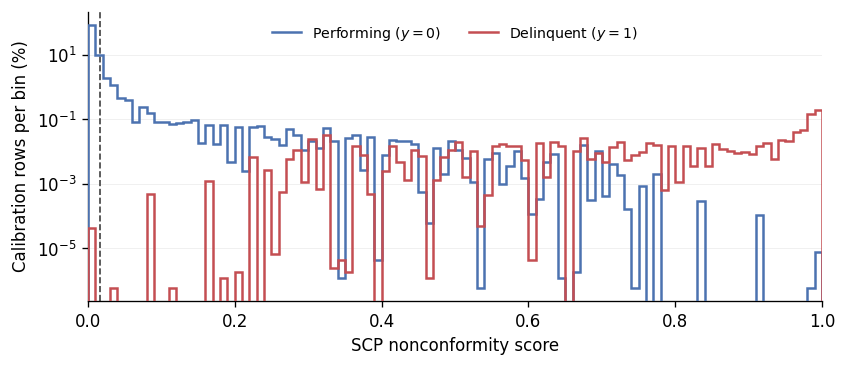

Figure 5.1 checks:
  cp_cal rows              : 161,421,966
  Performing rows          : 159,634,336 (98.8926%)
  Delinquent rows          : 1,787,630 (1.1074%)
  SCP threshold            : 0.01622366
  Coverage(y=0)            : 91.313849%
  Coverage(y=1)            : 0.003860%
  Figure data              : /content/drive/MyDrive/master_thesis/results/nb05b/fig5_1_scp_score_distribution.csv
  Figure                   : /content/drive/MyDrive/master_thesis/results/nb05b/figures/fig5_1_scp_score_distribution.png
  Figure PDF               : /content/drive/MyDrive/master_thesis/results/nb05b/figures/fig5_1_scp_score_distribution.pdf


In [ ]:
# ─── §2.1 · Figure 4.1 - SCP nonconformity-score mass by class ──────────────
import matplotlib.ticker as mticker

FIG51_N_BINS = 100

# ---------------------------------------------------------------------------
# 1. Exact pooled-mass histogram on the full cp_cal partition
# ---------------------------------------------------------------------------

bin_edges = np.linspace(
    0.0,
    1.0,
    FIG51_N_BINS + 1,
    dtype=np.float64,
)

# Compute class-specific counts separately to limit temporary memory use.
y0_counts, _ = np.histogram(
    SCORES_SCP[Y_CAL == 0],
    bins=bin_edges,
)

y1_counts, _ = np.histogram(
    SCORES_SCP[Y_CAL == 1],
    bins=bin_edges,
)

n_total = int(N_CP_CAL_ACTUAL)
n_y0 = int(y0_counts.sum())
n_y1 = int(y1_counts.sum())

assert n_y0 + n_y1 == n_total
assert n_total == 161_421_966

# Each height is the share of the ENTIRE cp_cal partition in that
# class × score bin. The two class profiles therefore preserve the
# class imbalance that determines the pooled conformal quantile.
y0_share_pct = y0_counts / n_total * 100.0
y1_share_pct = y1_counts / n_total * 100.0

assert np.isclose(
    y0_share_pct.sum() + y1_share_pct.sum(),
    100.0,
    atol=1e-10,
)

# Locked thesis anchors from the immediately preceding SCP-calibration cell.
assert f"{float(Q_HAT_SCP):.6f}" == "0.016224"
assert f"{pos_rate * 100:.4f}" == "1.1074"
assert f"{scp_cov['coverage_y0'] * 100:.4f}" == "91.3138"
assert f"{scp_cov['coverage_y1'] * 100:.4f}" == "0.0039"


# ---------------------------------------------------------------------------
# 2. Save exact data behind the figure
# ---------------------------------------------------------------------------

fig51_data = pl.DataFrame({
    "bin_left": bin_edges[:-1],
    "bin_right": bin_edges[1:],
    "bin_mid": (bin_edges[:-1] + bin_edges[1:]) / 2.0,
    "y0_count": y0_counts,
    "y1_count": y1_counts,
    "y0_share_cpcal_pct": y0_share_pct,
    "y1_share_cpcal_pct": y1_share_pct,
})

fig51_data_path = (
    RESULTS_DIR
    / "nb05b"
    / "fig5_1_scp_score_distribution.csv"
)

fig51_data.write_csv(fig51_data_path)


# ---------------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.0, 3.0)
)

# Zero-mass bins are omitted on the logarithmic axis rather than relocated.
y0_plot = np.where(
    y0_share_pct > 0,
    y0_share_pct,
    np.nan,
)

y1_plot = np.where(
    y1_share_pct > 0,
    y1_share_pct,
    np.nan,
)

ax.stairs(
    y0_plot,
    bin_edges,
    color="#4C72B0",
    linewidth=1.5,
    label=r"Performing ($y=0$)",
    zorder=3,
)

ax.stairs(
    y1_plot,
    bin_edges,
    color="#C44E52",
    linewidth=1.5,
    label=r"Delinquent ($y=1$)",
    zorder=3,
)

ax.axvline(
    float(Q_HAT_SCP),
    color="0.25",
    linestyle="--",
    linewidth=1.0,
    zorder=2,
)

ax.set_yscale("log")

ax.set_xlim(0.0, 1.0)
ax.set_xticks(
    np.arange(0.0, 1.01, 0.2)
)

ax.set_xlabel(
    "SCP nonconformity score"
)

ax.set_ylabel(
    "Calibration rows per bin (%)"
)

ax.grid(False)
ax.grid(
    axis="y",
    alpha=0.18,
    linewidth=0.6,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=8.5,
)

fig.tight_layout(
    pad=0.5
)

fig51_path = (
    FIGURES_DIR
    / "fig5_1_scp_score_distribution.png"
)

fig51_pdf_path = fig51_path.with_suffix(".pdf")

# Raster copy for notebook / quick inspection
fig.savefig(
    fig51_path,
    dpi=300,
    bbox_inches="tight",
)

# Vector copy for the thesis
fig.savefig(
    fig51_pdf_path,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------------------------
# 4. Compact audit output
# ---------------------------------------------------------------------------

print("Figure 5.1 checks:")
print(f"  cp_cal rows              : {n_total:,}")
print(f"  Performing rows          : {n_y0:,} ({n_y0 / n_total:.4%})")
print(f"  Delinquent rows          : {n_y1:,} ({n_y1 / n_total:.4%})")
print(f"  SCP threshold            : {float(Q_HAT_SCP):.8f}")
print(f"  Coverage(y=0)            : {scp_cov['coverage_y0']:.6%}")
print(f"  Coverage(y=1)            : {scp_cov['coverage_y1']:.6%}")
print(f"  Figure data              : {fig51_data_path}")
print(f"  Figure                   : {fig51_path}")
print(f"  Figure PDF               : {fig51_pdf_path}")

---
## Section 3 · Mondrian CP - Group-Conditional Thresholds

Mondrian / group-balanced conformal prediction computes separate conformal thresholds
inside pre-specified, non-overlapping groups. For a group $k$, let

$$
\mathcal I_k = \{i : g(X_i)=k\},
\qquad
n_k = |\mathcal I_k|,
$$

and let $s_{k,(j)}$ denote the $j$-th smallest calibration score among observations in
group $k$. The group-specific split-conformal threshold is

$$
\hat q_k
=
s_{k,(\lceil (n_k+1)(1-\alpha)\rceil)}.
$$

For a new observation with observed group $g(x)$, the corresponding prediction set is

$$
\hat C(x)
=
\{y : s(x,y) \leq \hat q_{g(x)}\}.
$$

This is the same finite-sample conformal quantile logic as in SCP, but applied separately
within each subgroup. The formal guarantee is group-conditional: under exchangeability
of calibration and test observations within each group, and provided the grouping rule is
fixed before calibration evaluation, observable at test time, and non-overlapping,

$$
P\!\left(
Y_{n+1} \in \hat C(X_{n+1})
\;\middle|\;
g(X_{n+1}) = k
\right)
\geq
1-\alpha
$$

for each group $k$. This is the group-conditional coverage guarantee
(Vovk, 2012, Proposition 3; Angelopoulos & Bates, 2023, Proposition 1).
Conditional additionally on the realised calibration group count $N_k=n_k$,
the usual tie-free split-conformal rank argument gives

$$
P\!\left(
Y_{n+1} \in \hat C(X_{n+1})
\;\middle|\;
g(X_{n+1}) = k,\; N_k=n_k
\right)
\leq
1-\alpha+\frac{1}{n_k+1}.
$$

With the float32-discretized scores used here, ties invalidate that upper bound,
so the subgroup numbers below are read as reliability diagnostics rather than
as exact near-tightness bounds.

The tie-free term $1/(n_k+1)$ is numerically negligible here: even the smallest
calibration cell has 17,312 rows. Group sizes are still reported because sample
fragmentation matters for stability and interpretation.

This is not full conditional coverage given $X=x$. It is a finite-partition conditional
guarantee. Full distribution-free conditional coverage at individual covariate values is
generally impossible without further restrictions or trivial prediction sets
(Vovk, 2012, Proposition 4; Lei & Wasserman, 2014; Foygel Barber et al., 2021), so the
subgroup results below should be interpreted as reliability diagnostics and groupwise
calibration benchmarks, not as unrestricted pointwise conditional coverage.

**Naming convention.** `FICO` in subgroup and method labels is implementation shorthand for thesis-defined tiers of the SFLLD `CREDIT SCORE`; Freddie Mac's supplied documentation does not identify the third-party scoring model.

Four subgroup variants are calibrated:

1. **FICO tier**: Subprime / Near-Prime / Prime / Sentinel.
2. **LTV bucket**: High / Moderate / Low / Sentinel.
3. **FICO × LTV**: cross-product of FICO tier and LTV bucket.
4. **Census division**: US Census geographic divisions.

The FICO, LTV, and FICO × LTV partitions are thesis-defined borrower-risk cells and
the main economic subgroup structure. Census division is included only as a coarse
geographic robustness partition; FICO × LTV remains the primary borrower-risk partition.

**Sentinel groups.** Loans with unavailable FICO or LTV values are assigned to Sentinel
groups rather than imputed into economic bins. This avoids applying a threshold calibrated
on observed Prime/Subprime or Low/High-LTV loans to records whose underlying credit or
collateral measure is unavailable. This is a data-contract decision that records an unavailable disclosed credit or collateral
measure as not-available rather than imputing it into an economic bin.

**Small-cell guard.** `min_rows = MONDRIAN_MIN_ROWS` is an interpretability and stability flag, not a
mathematical requirement of conformal prediction. Thresholds are still computed and
serialized for all non-empty cells. However, cells below this size are flagged so downstream
notebooks can treat them cautiously in sensitivity checks. In the current `cp_cal` split, the main FICO × LTV cells
are far above this threshold.

In [ ]:
# ─── §3 · Mondrian CP - all four variants ────────────────────────────────────

# Minimum cp_cal rows per group for stability flagging (not a formal validity condition).
# Note: NB03 uses MONDRIAN_MIN_CELL = 500 distinct loans for the panel-construction
# viability check; these thresholds measure different things (cp_cal rows vs distinct
# calibration loans) and need not be equal.
MONDRIAN_MIN_ROWS = 1000

def mondrian_thresholds(
    scores: np.ndarray,
    groups: np.ndarray,
    alpha: float = ALPHA,
    min_rows: int = MONDRIAN_MIN_ROWS,
) -> dict[str, dict]:
    """
    Compute per-group Mondrian / group-balanced split-conformal thresholds.

    For each non-empty group g, computes the ceil((n_g + 1) * (1 - alpha))-th
    smallest calibration score within that group:

        q_hat_g = the ceil((n_g + 1) * (1 - alpha))-th order statistic
                  of the calibration scores restricted to group g.

    The resulting thresholds satisfy the group-conditional coverage guarantee

        P(Y_{n+1} in C(X_{n+1}) | g(X_{n+1}) = g) >= 1 - alpha

    for each group g, under exchangeability of calibration and test observations
    within that group, provided the grouping rule is fixed before calibration,
    observable at test time, and non-overlapping (Vovk, 2012, Proposition 3).

    Conditional additionally on the realised calibration group count N_g = n_g,
    the usual tie-free split-conformal rank argument gives the upper bound
    1 - alpha + 1/(n_g + 1). That upper bound does not apply to tied scores.

    The `eligible` flag is an interpretability/stability flag only; it is not a
    requirement for the mathematical conformal construction.

    Parameters
    ----------
    scores : 1-D array
        Calibration nonconformity scores.
    groups : 1-D array
        Pre-specified group labels, one per calibration observation.
    alpha : float
        Miscoverage level.
    min_rows : int
        Minimum cell size for the stability/interpretability flag.

    Returns
    -------
    dict
        {group_label: {'q_hat': float, 'n_rows': int, 'eligible': bool}}
        q_hat is stored as Python float for JSON serialisation; NB06 casts to
        np.float32 before score comparison.
    """
    scores = np.asarray(scores)
    groups = np.asarray(groups)

    if scores.ndim != 1:
        raise ValueError(f"`scores` must be 1-D, got shape {scores.shape}.")
    if groups.ndim != 1:
        raise ValueError(f"`groups` must be 1-D, got shape {groups.shape}.")
    if len(scores) != len(groups):
        raise ValueError(
            f"`scores` and `groups` must have the same length; "
            f"got {len(scores):,} and {len(groups):,}."
        )
    if len(scores) == 0:
        raise ValueError("Cannot compute Mondrian thresholds on an empty score array.")

    # Group labels should already contain explicit Sentinel values for missingness.
    # Casting to string makes sorting and JSON serialization deterministic.
    group_labels = groups.astype(str)
    unique_groups = sorted(np.unique(group_labels))

    result: dict[str, dict] = {}

    for grp in unique_groups:
        mask = group_labels == grp
        n_grp = int(mask.sum())

        if n_grp == 0:
            continue

        s_grp = scores[mask]
        q = cp_quantile(s_grp, alpha)
        eligible = n_grp >= min_rows

        if not eligible:
            print(
                f'  Warning: group "{grp}" has only {n_grp:,} rows; '
                f'threshold is computed but per-group slack 1/(n_g+1) = '
                f'{1/(n_grp+1):.4f} - interpret cautiously.'
            )

        result[str(grp)] = {
            'q_hat': float(q),      # stored as Python float; NB06 casts to np.float32
            'n_rows': n_grp,
            'eligible': eligible,
        }

    return result


print('Computing Mondrian thresholds for all four variants ...')
t0 = time.time()

MONDRIAN_FICO     = mondrian_thresholds(SCORES_SCP, FICO_TIER,  ALPHA)
MONDRIAN_LTV      = mondrian_thresholds(SCORES_SCP, LTV_BUCKET, ALPHA)
MONDRIAN_FICO_LTV = mondrian_thresholds(SCORES_SCP, FICO_LTV,   ALPHA)
MONDRIAN_CENSUS   = mondrian_thresholds(SCORES_SCP, CENSUS_DIV, ALPHA)

elapsed = time.time() - t0
print(f'  Computed in {elapsed:.1f}s')

# ── Display results ───────────────────────────────────────────────────────────
q_scp = np.float32(Q_HAT_SCP)

print(f'\n  SCP threshold (reference): {float(q_scp):.8f}')

print('\n  FICO tier:')
print(f'  {"Group":<22}  {"q_hat":>10}  {"ratio/SCP":>10}  {"n_rows":>12}  {"slack_1/(n+1)":>14}  {"eligible":>10}')
for grp, info in sorted(MONDRIAN_FICO.items()):
    ratio = info['q_hat'] / float(q_scp) if float(q_scp) > 0 else float('nan')
    slack = 1.0 / (info['n_rows'] + 1)
    print(
        f'  {grp:<22}  {info["q_hat"]:>10.6f}  {ratio:>10.2f}×  '
        f'{info["n_rows"]:>12,}  {slack:>14.2e}  {str(info["eligible"]):>10}'
    )

print('\n  LTV bucket:')
print(f'  {"Group":<22}  {"q_hat":>10}  {"ratio/SCP":>10}  {"n_rows":>12}  {"slack_1/(n+1)":>14}  {"eligible":>10}')
for grp, info in sorted(MONDRIAN_LTV.items()):
    ratio = info['q_hat'] / float(q_scp) if float(q_scp) > 0 else float('nan')
    slack = 1.0 / (info['n_rows'] + 1)
    print(
        f'  {grp:<22}  {info["q_hat"]:>10.6f}  {ratio:>10.2f}×  '
        f'{info["n_rows"]:>12,}  {slack:>14.2e}  {str(info["eligible"]):>10}'
    )

print('\n  FICO × LTV (main Mondrian borrower-risk cells for RQ1/RQ2 analysis):')
print(f'  {"Group":<28}  {"q_hat":>10}  {"ratio/SCP":>10}  {"n_rows":>12}  {"slack_1/(n+1)":>14}  {"eligible":>10}')

# For the economic threshold-spread summary, exclude all Sentinel-containing cells.
# This avoids mixing missing-value sentinel groups with observed borrower-risk cells.
q_vals_observed = [
    info['q_hat']
    for grp, info in MONDRIAN_FICO_LTV.items()
    if 'Sentinel' not in str(grp) and np.isfinite(info['q_hat'])
]

for grp, info in sorted(MONDRIAN_FICO_LTV.items()):
    ratio = info['q_hat'] / float(q_scp) if float(q_scp) > 0 else float('nan')
    slack = 1.0 / (info['n_rows'] + 1)
    print(
        f'  {grp:<28}  {info["q_hat"]:>10.6f}  {ratio:>10.2f}×  '
        f'{info["n_rows"]:>12,}  {slack:>14.2e}  {str(info["eligible"]):>10}'
    )

if q_vals_observed:
    print(
        f'\n  FICO×LTV threshold spread, observed non-sentinel cells: '
        f'{max(q_vals_observed) / min(q_vals_observed):.1f}× '
        f'(max={max(q_vals_observed):.6f}, min={min(q_vals_observed):.6f})'
    )
else:
    print('\n  FICO×LTV threshold spread: no observed non-sentinel cells available.')

print('\n  Census division:')
print(f'  {"Division":<28}  {"q_hat":>10}  {"n_rows":>12}  {"slack_1/(n+1)":>14}  {"eligible":>10}')
for grp, info in sorted(MONDRIAN_CENSUS.items()):
    slack = 1.0 / (info['n_rows'] + 1)
    print(
        f'  {grp:<28}  {info["q_hat"]:>10.6f}  '
        f'{info["n_rows"]:>12,}  {slack:>14.2e}  {str(info["eligible"]):>10}'
    )

Computing Mondrian thresholds for all four variants ...
  Computed in 260.5s

  SCP threshold (reference): 0.01622366

  FICO tier:
  Group                        q_hat   ratio/SCP        n_rows   slack_1/(n+1)    eligible
  Near-Prime                0.024451        1.51×    51,512,885        1.94e-08        True
  Prime                     0.004539        0.28×    99,112,743        1.01e-08        True
  Sentinel                  0.019110        1.18×       539,054        1.86e-06        True
  Subprime                  0.234527       14.46×    10,257,284        9.75e-08        True

  LTV bucket:
  Group                        q_hat   ratio/SCP        n_rows   slack_1/(n+1)    eligible
  High                      0.059754        3.68×     1,019,970        9.80e-07        True
  Low                       0.012462        0.77×   141,710,631        7.06e-09        True
  Moderate                  0.049727        3.07×    18,674,053        5.36e-08        True
  Sentinel                 

---
## Section 4 · APS - Adaptive Prediction Sets

Adaptive Prediction Sets (APS) use a classification-specific conformal score based on
the cumulative predicted probability mass induced by the model's class ranking. Romano,
Sesia and Candès (2020) develop the randomized generalized inverse quantile conformity
score for unordered classification labels and show that the resulting conformal prediction
sets retain finite-sample marginal coverage under exchangeability, while often improving
adaptivity relative to simpler classification scores. Angelopoulos and Bates (2023) present
a deterministic (non-randomized) variant of the same score for expositional clarity; this
notebook uses Romano et al.'s randomized form, which is described below.

NB05a computed a randomized APS score following Romano, Sesia and Candès (2020),
Equation (7). Theirs is the generalized inverse quantile conformity score defined as the
minimum $\tau \in [0,1]$ such that label $y$ is included in the cumulative-probability
prediction set $S(x, u; \hat\pi, \tau)$. Working this through explicitly for the label
$y$ with estimated probability $\hat\pi_y(x)$ and all higher-ranked labels summing to
$p_\mathrm{above}(x,y) = \sum_{z:\,\hat{\pi}_z(x) > \hat{\pi}_y(x)} \hat{\pi}_z(x)$,
the minimum threshold resolves to

$$
s^{\mathrm{APS}}(x,y,U)
=
\sum_{z:\,\hat{\pi}_z(x) > \hat{\pi}_y(x)}
\hat{\pi}_z(x)
+
\hat{\pi}_y(x)(1-U),
\qquad
U \sim \mathrm{Uniform}(0,1).
$$

where $\hat{\pi}_y(x)$ is the calibrated model probability assigned to label $y$.
The first term is the total predicted probability mass of labels ranked strictly above $y$;
the second term randomizes uniformly within the probability mass of label $y$. Writing
$V = 1-U \sim \mathrm{Uniform}(0,1)$, this has the same marginal distribution as
$p_\mathrm{above} + V\hat\pi_y(x)$.

**Note on Romano et al. (2020) Algorithm 1.** Step 6 prints the
$\lceil(1-\alpha)(1+n)\rceil$-th largest calibration score, whereas Theorem 1 and the
surrounding $1-\alpha$ quantile construction are consistent with the lower-order-statistic
convention used here. This notebook therefore uses the standard split-conformal
$\lceil(n+1)(1-\alpha)\rceil$-th smallest score.

**Tie-handling.** If predicted class probabilities tie, a ranking convention is required.
NB05a resolves the binary rank tie with its `>=` rule before applying the randomized
within-label term. NB05b uses the resulting stored APS scores and audits their rank/tie
arithmetic directly.

NB05b does not recompute this score. It loads `score_aps` from the calibration-score
files and calibrates a single global threshold using the standard finite-sample
split-conformal quantile:

$$
\hat q_{\mathrm{APS}}
=
s^{\mathrm{APS}}_{(\lceil (n+1)(1-\alpha)\rceil)},
$$

i.e., the $\lceil(n+1)(1-\alpha)\rceil$th smallest calibration score. The corresponding
APS prediction set for a test point $(x, u)$ is

$$
\hat C_{\mathrm{APS}}(x;u)
=
\{y : s^{\mathrm{APS}}(x,y,u) \leq \hat q_{\mathrm{APS}}\}.
$$

The finite-sample marginal coverage guarantee follows from Romano et al. (2020),
Theorem 1. Under exchangeability of calibration and test observations and independence
of the uniform randomization:

$$
1-\alpha
\;\leq\;
P\!\left[Y_{n+1} \in \hat C_{\mathrm{APS}}(X_{n+1})\right]
\;\leq\;
1-\alpha+\frac{1}{n+1},
$$

where the probability is over both the exchangeable data and the algorithmic
randomization $U_{n+1}$. The upper bound holds when calibration APS scores are almost
surely distinct, which the randomized construction guarantees for continuous score
distributions. It is not a guarantee of class-conditional coverage, borrower-subgroup
coverage, or temporal coverage.

**Randomization and reproducibility.** The theoretical construction uses independent
uniform draws across observations. NB05a generates and stores randomized true-label
`score_aps` values for calibration and every test split using deterministic split/year-specific
pseudo-random streams. NB06 uses those stored scores for true-label APS coverage; its
separate auxiliary draw is used only to reconstruct the other-label score for prediction-set
composition.

**Why APS is relevant here.** SCP with $s(x,y)=1-\hat p_y(x)$ produces near-zero
coverage for the rare positive class in this notebook. APS changes the classification-score
geometry: instead of using only the true-label probability, it uses the cumulative model
ranking and randomizes within the true-label mass. This makes APS a useful diagnostic for
asking whether the event-class collapse is specific to the standard SCP score rather than
unavoidable given the calibrated probability backbone.

**Interpretation of the Prime × Low reversal.** In a severely imbalanced binary setting,
many Prime × Low performing loan-months have very high predicted performing probability
$\hat p(0\mid x) \approx 1$. For such observations, the true-label APS score for the
performing label is

$$
s^{\mathrm{APS}}(x, 0, U) = \hat p(0\mid x)\,(1-U) \approx 1-U,
$$

since $p_\mathrm{above}(x,0) = 0$ when $\hat p_0$ is the highest probability. This score
exceeds the threshold $\hat q_\mathrm{APS}$ whenever $U < 1-\hat q_\mathrm{APS}$, which
occurs with probability $1-\hat q_\mathrm{APS} > 0$ as long as $\hat q_\mathrm{APS} < 1$.
Therefore, APS may improve positive-class coverage while simultaneously producing
miscoverage for a fraction of high-confidence majority-class observations in certain
subgroups. This Prime × Low reversal is an empirical finding of this mortgage application.
Romano, Sesia and Candès (2020) justify the APS score construction but do not state this
mortgage-specific subgroup reversal.

**Set-valued classification interpretation.** APS and SCP both produce set-valued
classifiers. Empty sets, singleton sets, and ambiguous two-label sets are part of the
method's efficiency and ambiguity profile, not merely implementation details. Sadinle,
Lei and Wasserman (2019) are relevant for this set-valued classification interpretation,
although they are not the source of the APS score itself.

In [ ]:
# ─── §4 · APS threshold ──────────────────────────────────────────────────────
print('Computing APS threshold ...')
t0 = time.time()

# APS scores are randomized cumulative-mass scores: s(x,y,U) = p_above + (1-U)*pi_y.
# By construction they lie in [0, 1]:
#   - p_above >= 0 and (1-U)*pi_y >= 0
#   - p_above + pi_y <= sum_z pi_z = 1
#   - (1-U) <= 1, so total <= p_above + pi_y <= 1
if not np.isfinite(SCORES_APS).all():
    raise ValueError("SCORES_APS contains non-finite values.")

aps_min = float(SCORES_APS.min())
aps_max = float(SCORES_APS.max())
if aps_min < -1e-7 or aps_max > 1.0 + 1e-7:
    raise ValueError(
        f"SCORES_APS should lie in [0, 1], got range [{aps_min:.8f}, {aps_max:.8f}]."
    )

Q_HAT_APS = cp_quantile(SCORES_APS, ALPHA)

print(f'  q_hat_APS = {Q_HAT_APS:.8f}  (float32: {Q_HAT_APS})')
print(f'  q_hat_SCP = {Q_HAT_SCP:.8f}  (different score scale; shown only for reference)')
print(f'  score_aps range = [{aps_min:.6f}, {aps_max:.6f}]')
print(f'  Computed in {time.time()-t0:.1f}s')

# ── Calibration-score diagnostic under APS ───────────────────────────────────
# This uses the same cp_cal scores that determine q_hat_APS. It is a diagnostic
# of calibration-score behavior, not an independent test-set validation.
aps_cov = coverage_rate(SCORES_APS, np.float32(Q_HAT_APS), Y_CAL)

print(f'\nAPS coverage on cp_cal calibration scores:')
print(f'  Marginal coverage    : {aps_cov["marginal"]:.6f}  (out-of-sample guarantee: ≥{1-ALPHA:.4f})')
print(f'  Coverage(y=0)        : {aps_cov["coverage_y0"]:.6f}')
print(f'  Coverage(y=1)        : {aps_cov["coverage_y1"]:.6f}')
print(f'  Miscoverage rate     : {aps_cov["miscoverage_rate"]:.6f}')

# ── Arithmetic decomposition of marginal APS coverage ────────────────────────
# By the law of total expectation:
#   MC = P(Y=0) * Coverage(Y=0) + P(Y=1) * Coverage(Y=1)
pos_rate = float(Y_CAL.mean())
aps_mc_reconstructed = (
    (1.0 - pos_rate) * aps_cov['coverage_y0']
    + pos_rate * aps_cov['coverage_y1']
)

print(f'\n  Marginal decomposition check:')
print(
    f'    {1-pos_rate:.4f} × {aps_cov["coverage_y0"]:.4f}  +  '
    f'{pos_rate:.4f} × {aps_cov["coverage_y1"]:.6f}  =  {aps_mc_reconstructed:.6f}'
)
print(f'  (matches marginal: {abs(aps_mc_reconstructed - aps_cov["marginal"]) < 1e-5})')

# ── Compare y=1 coverage: SCP vs APS ─────────────────────────────────────────
print(f'\nLevel-1 class-conditional collapse comparison:')
print(f'  Coverage(y=1) under SCP : {scp_cov["coverage_y1"]:.6f}')
print(f'  Coverage(y=1) under APS : {aps_cov["coverage_y1"]:.6f}')
print(f'  Difference              : {(aps_cov["coverage_y1"] - scp_cov["coverage_y1"])*100:+.2f} pp')

Computing APS threshold ...
  q_hat_APS = 0.89995086  (float32: 0.8999508619308472)
  q_hat_SCP = 0.01622366  (different score scale; shown only for reference)
  score_aps range = [0.000000, 1.000000]
  Computed in 1.3s

APS coverage on cp_cal calibration scores:
  Marginal coverage    : 0.900000  (out-of-sample guarantee: ≥0.9000)
  Coverage(y=0)        : 0.905867
  Coverage(y=1)        : 0.376046
  Miscoverage rate     : 0.100000

  Marginal decomposition check:
    0.9889 × 0.9059  +  0.0111 × 0.376046  =  0.900000
  (matches marginal: True)

Level-1 class-conditional collapse comparison:
  Coverage(y=1) under SCP : 0.000039
  Coverage(y=1) under APS : 0.376046
  Difference              : +37.60 pp


---
## Section 5 · ACI / DtACI - Adaptive Conformal Inference

Adaptive Conformal Inference (ACI) is an online conformal method that updates the
miscoverage parameter sequentially as observations arrive (Gibbs & Candès, 2021).
The method treats the conformal quantile level as a tunable online parameter. At time
$t$, for a candidate value $\beta$, the prediction set can be written abstractly as

$$
\hat C_t(\beta)
=
\{y : S_t^y \leq \operatorname{Quantile}(1-\beta, D_t^y)\},
$$

where $S_t^y$ is the candidate-label conformity score and $D_t^y$ is the reference
score distribution used at time $t$, with the convention
$\operatorname{Quantile}(\tau, D) = +\infty$ for $\tau \geq 1$ and $-\infty$ for
$\tau \leq 0$ (Gibbs & Candès, 2024, p. 4). ACI updates

$$
\alpha_{t+1}
=
\alpha_t + \gamma(\alpha-\operatorname{err}_t),
\qquad
\mathrm{err}_t
=
\mathbf 1\{Y_t \notin \hat C_t(\alpha_t)\}.
$$

**Downstream deployment adaptation.** The published recursion above is per observation.
NB06 instead aggregates row-level misses to the realised miscoverage rate
$\widehat e_m$ of calendar month $m$ and applies

$$
\alpha_{m+1}
=
\operatorname{clip}\!\left(
\alpha_m+\gamma(\alpha-\widehat e_m),\,0,\,1
\right)
$$

once per observed month. The state is carried across all 196 observed test months. The
clipping is a deployment safeguard; the published recursion is unclipped, with Gibbs and
Candès (2021, Lemma 4.1) bounding its state in $[-\gamma,1+\gamma]$.

If the method misses, $\mathrm{err}_t=1$, so $\alpha_t$ decreases; a lower $\alpha_t$
produces a higher quantile level $1-\alpha_t$, raising the threshold and enlarging the
prediction set. If the method covers, $\mathrm{err}_t=0$, $\alpha_t$ increases, the
quantile level falls, and the prediction set shrinks. The step size $\gamma$ controls
the speed of this reaction.

**Long-run guarantee (Gibbs & Candès, 2021, Proposition 4.1).** Proposition 4.1
places no restriction on the data-generating process and gives:

$$
\left|\frac{1}{T}\sum_{t=1}^T \mathrm{err}_t - \alpha\right|
\;\leq\;
\frac{\max\{\alpha_1,\,1-\alpha_1\}+\gamma}{\gamma T}
\;\xrightarrow{T\to\infty}\; 0 \quad \text{a.s.}
$$

This is the published per-observation long-run frequency guarantee, not a finite-sample
marginal guarantee at a single time step. It is not claimed for the monthly clipped
deployment adaptation used in NB06.

**Local-regret and coverage connection (Gibbs & Candès, 2024, Theorem 4 and
Proposition 5).** Theorem 4 controls DtACI's average excess pinball loss over a
local interval relative to a time-varying comparator. The regret result itself does
not require a stochastic model for the data-generating sequence. Converting excess
pinball loss into a bound on $(\alpha_t-\alpha_t^*)^2$ additionally requires the
density condition of Proposition 5, and interpreting that parameter error as a local
coverage bound additionally requires the paper's Lipschitz condition on
$\beta\mapsto P(Y_t\in\hat C_t(\beta)\mid\{\beta_s\}_{s<t})$. These published
coverage statements therefore should not be read as unconditional consequences of
Theorem 4 alone.

Four single-$\gamma$ ACI variants are initialized:

$$
\gamma \in \{0.005, 0.01, 0.02, 0.05\}
$$

This grid provides slow-to-fast adaptation regimes for later chronological evaluation
in NB06.

**Fixed-reference implementation used here.** NB05b stores one sorted `score_scp`
calibration array and NB06 uses it as a fixed reference distribution for threshold
lookup. The implemented ACI/DtACI variants adapt $\alpha_t$, but they do not
re-estimate the calibration-score distribution $D_t$ over time. This is a practical
fixed-reference ACI/DtACI design. It should not be described as the fully general
time-updating $D_t$ implementation discussed in Gibbs and Candès (2024).

**DtACI.** Dynamically-Tuned ACI (DtACI) extends ACI by running $K$ ACI experts
with different step sizes $\gamma_i$ and adapting their weights over time (Gibbs &
Candès, 2024). DtACI is dynamically tuned; it is not "doubly robust." Gibbs and
Candès (2024) present two variants: Algorithm 1 (randomized - outputs $\alpha^i_t$
sampled with probability $p^i_t$) and Algorithm 2 (deterministic - outputs the
probability-weighted average $\bar\alpha_t = \sum_i p^i_t \alpha^i_t$). Corollary 7
of Gibbs and Candès (2024) shows both variants satisfy the same regret bound.
NB06 uses the deterministic weighted-average aggregation template (Algorithm 2),
removing randomness from the output.

The DtACI update (Algorithm 1 / Algorithm 2 of Gibbs & Candès, 2024, itself a
modification of Gradu et al., 2023) involves per-step:
1. Computing expert probabilities $p^i_t = w^i_t / \sum_j w^j_t$.
2. Outputting $\alpha_t$ (Algorithm 1: sample $\alpha^i_t$ with prob $p^i_t$;
   Algorithm 2: weighted average $\bar\alpha_t = \sum_i p^i_t \alpha^i_t$).
3. Updating expert weights via the pinball loss:
   $\bar w^i_t = w^i_t \exp(-\eta\,\ell(\beta_t, \alpha^i_t))$.
4. Mixing weights: $w^i_{t+1} = (1-\sigma)\bar w^i_t + \bar W_t\,\sigma/K$.
5. Updating each expert: $\alpha^i_{t+1} = \alpha^i_t + \gamma_i(\alpha - \mathrm{err}^i_t)$.

NB05b does not execute the DtACI online loop; it serializes the initial expert state.
NB06 uses the deterministic weighted-average aggregation template, but updates monthly:
each expert is evaluated at its own threshold and its realised monthly miscoverage replaces
the paper's shared per-observation $\beta_t$ in the pinball loss. This is an empirical
deployment adaptation, so the published DtACI guarantees are not claimed.

**DtACI hyperparameters: $\sigma$ and $\eta$.** The notebook stores a pool of $K=500$
candidate ACI experts with geometrically spaced step sizes. The parameters are set using
the reference interval $|I|=500$, matching the experimental tuning choice in Gibbs and Candès (2024, p. 10).

For $\sigma$, the paper's optimal choice is $\sigma = 1/(2|I|)$, giving

$$
\sigma = \frac{1}{2 \times 500} = 0.001.
$$

Note that $|I|=500$ is a time-interval length in the local-regret analysis, not the
number of experts $K$; the numerical coincidence $K = |I| = 500$ does not mean
$\sigma = 1/(2K)$ in general.

For $\eta$, the paper's fixed heuristic uses the idealized approximation
$E[\ell(\beta_t, \alpha_t)^2] \approx (1-\alpha)^2\alpha^2/3$ (which holds when
$\beta_t \sim \mathrm{Uniform}(0,1)$ and $\alpha_t \approx \alpha$), giving

$$
\eta = \sqrt{\frac{\log(2K|I|)+1}{|I| \cdot \frac{(1-\alpha)^2\alpha^2}{3}}}.
$$

With $K=500$ experts, $|I|=500$, and $\alpha=0.10$:

$$
\eta = \sqrt{\frac{\ln(2 \times 500 \times 500)+1}{500 \times \frac{0.81 \times 0.01}{3}}}
= \sqrt{\frac{\ln(500{,}000)+1}{1.35}}
= \sqrt{\frac{14.122}{1.35}}
\approx 3.234.
$$

**Theorem 4 grid condition.** Gibbs and Candès (2024, Theorem 4) additionally require
$\gamma_k \geq \sqrt{1+1/|I|}$. With $|I|=500$, this is approximately $1.001$.
The notebook uses $\gamma_{\max}=0.5$, so this sufficient condition is not met and no
Theorem-4 local-regret or derived local-coverage guarantee is claimed for the downstream
adaptation.

**Scope - global adaptation only.** ACI and DtACI use one global calibration-score
reference and one sequential update path across all observed test months. NB06 evaluates
their outputs marginally, class-conditionally, and temporally, but no separate per-cell
$\alpha_{t,k}$ process is implemented. They adapt temporal marginal miscoverage and do
not enforce group-conditional coverage.

**Threshold lookup during NB06.** At each time step, the threshold is obtained from
the sorted `score_scp` calibration array using the finite-sample conformal quantile
convention. Let

$$
\tau_t = 1-\alpha_t,
\qquad
k_t = \lceil(n+1)\tau_t\rceil.
$$

If $\tau_t \leq 0$, the threshold is $-\infty$; if $k_t>n$, it is $+\infty$;
otherwise it is `sorted_scores[k_t - 1]`. The sorted array is saved as
`aci_cal_scores.npy` for efficient downstream lookup.

**Critical sequential order requirement.** ACI and DtACI must process test observations
in strict chronological order by `obs_month`. Randomly shuffling the test sequence
destroys the online interpretation of the update rule and invalidates the sequential
evaluation design.

In [ ]:
# ─── §5 · ACI / DtACI initialisation state ───────────────────────────────────

# ── §5.1 · Sorted calibration score array for quantile lookup ────────────────
# Saved as float32 .npy.
#
# NB06 loads this array and performs index-based quantile lookup at each step t.
# The lookup must follow the same finite-sample convention as cp_quantile:
#
#   tau_t = 1 - alpha_t
#   if tau_t <= 0:
#       q_t = -inf
#   else:
#       k_t = ceil((n + 1) * tau_t)
#       if k_t > n:
#           q_t = +inf
#       else:
#           q_t = sorted_scores[k_t - 1]
#
# No capping of k_t at n; an adjusted rank above n corresponds to the
# +inf finite-sample conformal boundary.
#
# This sorted array is a fixed reference distribution. The ACI/DtACI variants
# adapt alpha_t over time but do not re-estimate the score distribution D_t
# unless NB06 explicitly implements such an update.
print('Sorting cp_cal score_scp array for ACI/DtACI fixed-reference threshold lookup ...')
t0 = time.time()

# ACI/DtACI adapts the miscoverage level α_t online, not the score function.
# It uses score_scp as the fixed calibration reference distribution by design:
# SCP and ACI share the same nonconformity score s(x,y) = 1 - p̂_cal(y|x),
# with ACI adding temporal adaptation of the threshold. There is no ACI+APS
# variant - APS is evaluated as a static method only.
ACI_SORTED_SCORES = np.sort(SCORES_SCP)   # float32, ascending; score_scp used by design
elapsed_sort = time.time() - t0

print(f'  Sorted {len(ACI_SORTED_SCORES):,} scores in {elapsed_sort:.1f}s')
print(f'  Array size: {ACI_SORTED_SCORES.nbytes / 1e9:.3f} GB')
print(f'  min={ACI_SORTED_SCORES[0]:.6f}  max={ACI_SORTED_SCORES[-1]:.6f}')

np.save(str(ACI_CAL_SCORES_PATH), ACI_SORTED_SCORES)
print(f'  Saved to {ACI_CAL_SCORES_PATH}')

# ── §5.2 · ACI initial state (one per gamma) ──────────────────────────────────
# ACI maintains a single alpha_t per gamma variant.
# Initial state: alpha_0 = ALPHA (global target miscoverage level).
# NB06 clones these states once and carries them continuously across all 196
# observed test months, without reset at regime boundaries. It applies one
# deployment-adapted update per month using that month's realised miscoverage:
#
#   alpha_{m+1} = clip(alpha_m + gamma * (ALPHA - miscov_m), 0, 1)
#
# The published ACI recursion instead uses a per-observation binary error.
# Its Proposition 4.1 long-run guarantee is not claimed for this monthly adaptation.
#
# Long-run guarantee for the published per-observation recursion
# (Gibbs & Candes 2021, Proposition 4.1):
#   |1/T * sum_{t=1}^T err_t - alpha|
#       <= (max{alpha_1, 1-alpha_1} + gamma) / (gamma*T) -> 0 a.s.
ACI_GAMMA_GRID = [0.005, 0.01, 0.02, 0.05]

aci_variants = {
    f'gamma_{g}'.replace('.', '_'): {
        'gamma'  : g,
        'alpha_0': ALPHA,
        'alpha_t': ALPHA,     # current state, initialized to alpha_0
    }
    for g in ACI_GAMMA_GRID
}

print(f'\nACI variants initialised: {list(aci_variants.keys())}')

# ── §5.3 · DtACI initial state (expert pool) ──────────────────────────────────
# K experts with geometrically spaced ACI step sizes.
# Initial weights: uniform 1/K.
#
# NB05b stores only the initial expert state; NB06 implements the chronological
# DtACI update loop. See the §5 markdown for the per-step Algorithm 1/2 definition.
DTACI_N_EXPERTS = 500

DTACI_REF_INTERVAL = 500
# Hyperparameter reference length matching the experimental tuning choice in
# Gibbs & Candes (2024). The downstream mortgage implementation has
# T=196 monthly steps, so |I|=500 is used only to instantiate eta and sigma;
# it is not an interval observed in the monthly evaluation sequence.
DTACI_SIGMA = 1.0 / (2 * DTACI_REF_INTERVAL)

# eta is the expert-weight learning rate from Gibbs & Candes (2024).
_n_log   = math.log(2 * DTACI_N_EXPERTS * DTACI_REF_INTERVAL) + 1
_denom   = DTACI_REF_INTERVAL * ((1 - ALPHA)**2 * ALPHA**2) / 3
DTACI_ETA = math.sqrt(_n_log / _denom)                 # ≈ 3.234 for K=500, alpha=0.10

print(f'\nDtACI eta computation:')
print(f'  K={DTACI_N_EXPERTS}, |I|={DTACI_REF_INTERVAL}, alpha={ALPHA}')
print(f'  ln(2*K*|I|) + 1 = {_n_log:.6f}')
print(f'  |I|*(1-alpha)^2*alpha^2/3 = {_denom:.6f}')
print(f'  DTACI_ETA = sqrt({_n_log:.4f} / {_denom:.4f}) = {DTACI_ETA:.6f}')

# Gamma grid: geometrically spaced from gamma_min to gamma_max.
# Note: Theorem 4 of Gibbs & Candes (2024) has a sufficient condition
# gamma_k >= sqrt(1 + 1/|I|). With |I|=500, this requires gamma_max >= ~1.001.
# The notebook uses gamma_max=0.5 < 1.001 (as do the paper's own experiments
# with gamma_max=0.128).
# Therefore the sufficient condition of Theorem 4 is not met by this grid.
# No Theorem-4 local-regret or local-coverage guarantee is claimed for the
# downstream monthly deployment adaptation.
DTACI_GAMMA_MIN = 0.001
DTACI_GAMMA_MAX = 0.5
dtaci_gamma_grid = np.geomspace(DTACI_GAMMA_MIN, DTACI_GAMMA_MAX, DTACI_N_EXPERTS).tolist()

dtaci_state = {
    'n_experts'       : DTACI_N_EXPERTS,
    'eta'             : DTACI_ETA,
    'sigma'           : DTACI_SIGMA,
    'gamma_min'       : DTACI_GAMMA_MIN,
    'gamma_max'       : DTACI_GAMMA_MAX,
    'gamma_grid'      : dtaci_gamma_grid,
    'alpha_0'         : ALPHA,
    'initial_alpha_t' : [ALPHA] * DTACI_N_EXPERTS,
    'initial_weights' : [1.0 / DTACI_N_EXPERTS] * DTACI_N_EXPERTS,
    'eta_derivation'  : (
        f'eta = sqrt((ln(2*K*|I|)+1) / (|I|*(1-alpha)^2*alpha^2/3)) '
        f'with K={DTACI_N_EXPERTS}, |I|=500, alpha={ALPHA}. '
        f'Formula-consistent for this expert pool size. '
        f'Reference repo (isgibbs/DtACI) uses eta≈2.72 calibrated to k=8 experts; '
        f'that value is not formula-consistent for K=500.'
    ),
}

print(f'\nDtACI expert pool:')
print(f'  K (n_experts)     : {DTACI_N_EXPERTS}')
print(f'  eta               : {DTACI_ETA:.6f}')
print(f'  sigma             : {DTACI_SIGMA}')
print(f'  gamma range       : [{dtaci_gamma_grid[0]:.6f}, {dtaci_gamma_grid[-1]:.4f}]')
print(f'  initial weights   : uniform (1/K = {1/DTACI_N_EXPERTS:.6f})')

# ── Serialize ACI init state ──────────────────────────────────────────────────
aci_init_state = {
    'alpha'              : ALPHA,
    'n_cp_cal'           : N_CP_CAL_ACTUAL,
    'sorted_scores_path' : str(ACI_CAL_SCORES_PATH),
    'aci_gamma_grid'     : ACI_GAMMA_GRID,
    'dtaci'              : dtaci_state,
    'fixed_reference_distribution': True,
}

with open(ACI_INIT_STATE_PATH, 'w') as f:
    json.dump(aci_init_state, f, indent=2)

print(f'\n✓  ACI init state written to {ACI_INIT_STATE_PATH}')

Sorting cp_cal score_scp array for ACI/DtACI fixed-reference threshold lookup ...
  Sorted 161,421,966 scores in 3.5s
  Array size: 0.646 GB
  min=0.000000  max=1.000000
  Saved to /content/drive/MyDrive/master_thesis/cp_artifacts/aci_cal_scores.npy

ACI variants initialised: ['gamma_0_005', 'gamma_0_01', 'gamma_0_02', 'gamma_0_05']

DtACI eta computation:
  K=500, |I|=500, alpha=0.1
  ln(2*K*|I|) + 1 = 14.122363
  |I|*(1-alpha)^2*alpha^2/3 = 1.350000
  DTACI_ETA = sqrt(14.1224 / 1.3500) = 3.234348

DtACI expert pool:
  K (n_experts)     : 500
  eta               : 3.234348
  sigma             : 0.001
  gamma range       : [0.001000, 0.5000]
  initial weights   : uniform (1/K = 0.002000)

✓  ACI init state written to /content/drive/MyDrive/master_thesis/cp_artifacts/aci_init_state.json


## Section 6 · Unit Tests

The unit tests verify:
1. **SCP threshold arithmetic:** global `cp_cal` coverage induced by the stored SCP
   threshold is consistent with the finite-sample conformal rank and the observed tie
   structure.
2. **Mondrian threshold arithmetic:** each non-empty group-specific threshold gives
   calibration-score coverage consistent with its own finite-sample rank and tie structure.
3. **APS threshold arithmetic:** the APS threshold is checked using the same conformal
   rank/tie logic. APS uses randomized scores; in this run the selected threshold has zero
   observed tie mass, and the float32 rank/tie check is retained explicitly.
4. **ACI round-trip:** JSON serialisation and deserialisation preserve the adaptive-method
   initialisation state.
5. **Float32 contract:** for every threshold, the float32 representation produces the same
   calibration coverage count as the float64 representation. This directly tests that no
   calibration score sits in the float32 rounding gap of any threshold.
6. **ACI sorted array:** `aci_cal_scores.npy` is monotonically non-decreasing and matches
   the saved file.

These tests are implementation checks, not independent test-period coverage
evaluation. They verify that the thresholds written by NB05b are arithmetically consistent
with the calibration scores from NB05a.

For a calibration group of size $n_k$, define

$$
r_k = \lceil (n_k+1)(1-\alpha)\rceil.
$$

If the selected conformal threshold is $q_k = s_{k,(r_k)}$ (the $r_k$-th order statistic
of the group-$k$ calibration scores), then the empirical calibration coverage satisfies

$$
\frac{r_k}{n_k}
\leq
\frac{1}{n_k}\sum_{i:\,g_i=k}\mathbf{1}\{s_i\le q_k\}
\leq
\frac{r_k - 1 + \#\{i:\,g_i=k,\; s_i=q_k\}}{n_k}.
$$

Both bounds are deterministic, arithmetic consequences of the definition of the
$r_k$-th order statistic:

- **Lower bound:** the first $r_k$ order statistics are all $\leq s_{k,(r_k)} = q_k$,
  so at least $r_k$ scores satisfy the indicator.
- **Upper bound:** let $t = \#\{i:\,g_i=k,\; s_i=q_k\}$ and let $j_{\mathrm{first}}$
  be the index of the first sorted score equal to $q_k$. Since $s_{k,(r_k)} = q_k$,
  we have $j_{\mathrm{first}} \leq r_k$. The number of scores strictly below $q_k$
  is therefore $j_{\mathrm{first}} - 1 \leq r_k - 1$, so the total count of scores
  $\leq q_k$ is at most $(r_k - 1) + t$.

These bounds are calibration-set arithmetic checks, not coverage theorems. They are
distinct from the probabilistic guarantee
$\mathbb{P}(Y_{\mathrm{test}} \in C(X_{\mathrm{test}})) \geq 1-\alpha$, which holds
for a fresh exchangeable test point and is established in Vovk, Gammerman and Shafer
(2005) and Angelopoulos and Bates (2023). The split-conformal quantile formula
$r_k = \lceil(n_k+1)(1-\alpha)\rceil$ used here is from those same references.
Mondrian CP - stratified calibration within fixed, disjoint groups - is introduced in
Vovk, Gammerman and Shafer (2005). The APS score construction follows Romano,
Sesia and Candès (2020).

In [ ]:
# ─── §6 · Unit tests ─────────────────────────────────────────────────────────
#
# These are implementation checks, not independent test-period reliability
# evaluations. They verify that NB05b thresholds are consistent with the cp_cal
# score arrays produced by NB05a.
#
# For a score array of size n and target coverage 1-alpha:
#
#   r = ceil((n + 1) * (1 - alpha))
#
# If r > n, the strict conformal convention is threshold = +inf and empirical
# calibration coverage = 1. Otherwise q = s_(r). With ties at q, empirical
# coverage lies in the interval:
#
#   lower bound : r / n
#       At least r scores satisfy s <= q, because the first r order statistics
#       are all <= s_(r) = q by definition.
#
#   upper bound : (r - 1 + tie_count(q)) / n
#       The first occurrence of q in the sorted array is at index j_first <= r,
#       so at most r-1 scores are strictly below q. Adding the tie_count scores
#       equal to q (all included under the <= rule) gives the maximum.
#
# Both bounds are deterministic arithmetic consequences of the quantile
# definition, not probabilistic coverage statements about test points.
#
# This rank/tie check is used for SCP, Mondrian, and APS. APS uses randomized
# scores; in this run the selected APS threshold has zero observed tie mass.
# The tie-aware check is retained to audit the stored float32 scores directly.

n_tests_pass = 0
n_tests_fail = 0

FP_EPS = 1e-6
TARGET_COV = 1.0 - ALPHA


def conformal_rank(alpha: float, n: int) -> int:
    """
    Finite-sample conformal order-statistic rank.

    Returns the 1-indexed rank r = ceil((n+1)(1-alpha)).
    """
    if n <= 0:
        raise ValueError("Cannot compute a conformal rank for an empty score array.")
    return int(np.ceil((n + 1) * (1.0 - alpha)))


def calibration_coverage_bounds(
    scores: np.ndarray,
    threshold: float,
    alpha: float = ALPHA,
) -> dict[str, float]:
    """
    Computatuion of exact rank/tie-aware calibration-coverage bounds for a stored threshold.

    The threshold is cast to float32 before computing coverage, matching the
    downstream float32 comparison contract.

    For an interior conformal rank (r <= n), if threshold = s_(r) exactly,
    the empirical calibration coverage under <= lies in the interval:

        lower bound: r / n
        upper bound: (r - 1 + tie_count(threshold)) / n

    Both bounds are arithmetic consequences of the quantile definition and
    hold under exact arithmetic. FP_EPS is applied in assert_rank_tie_coverage
    solely as a floating-point comparison tolerance for the coverage fraction
    itself - it is not a single-observation boundary tolerance.

    Boundary cases:
    - r > n or threshold = +inf: strict conformal convention gives
      threshold = +inf and coverage = 1. Bounds returned as
      [1.0, 1.0 + FP_EPS] to allow floating-point comparison.
    - threshold = -inf: degenerate - no finite score satisfies s <= -inf,
      so coverage = 0. Bounds returned as [0.0, FP_EPS]. This case should
      not arise in valid conformal calibration.
    """
    scores = np.asarray(scores)

    if scores.ndim != 1:
        raise ValueError(f"`scores` must be 1-D, got shape {scores.shape}.")
    if len(scores) == 0:
        raise ValueError("Cannot check coverage bounds for an empty score array.")

    n = len(scores)
    r = conformal_rank(alpha, n)
    q = np.float32(threshold)

    actual_cov = float((scores <= q).mean())

    if np.isposinf(q) or r > n:
        return {
            "n": n,
            "rank": r,
            "tie_count": 0,
            "tie_mass": 0.0,
            "actual_cov": actual_cov,
            "lower": 1.0,
            "upper": 1.0 + FP_EPS,
        }

    if np.isneginf(q):
        return {
            "n": n,
            "rank": r,
            "tie_count": 0,
            "tie_mass": 0.0,
            "actual_cov": actual_cov,
            "lower": 0.0,
            "upper": 0.0 + FP_EPS,
        }

    tie_count = int((scores == q).sum())
    tie_mass = tie_count / n

    lower = r / n
    upper = (r - 1 + tie_count) / n + FP_EPS

    return {
        "n": n,
        "rank": r,
        "tie_count": tie_count,
        "tie_mass": tie_mass,
        "actual_cov": actual_cov,
        "lower": lower,
        "upper": min(1.0 + FP_EPS, upper),
    }


def assert_test(condition: bool, name: str, detail: str = '') -> None:
    global n_tests_pass, n_tests_fail
    if condition:
        print(f'  ✓  {name}')
        n_tests_pass += 1
    else:
        print(f'  ✗  FAIL: {name}  {detail}')
        n_tests_fail += 1


def assert_rank_tie_coverage(
    scores: np.ndarray,
    threshold: float,
    name: str,
) -> dict[str, float]:
    """
    Assert that empirical calibration coverage is consistent with the stored
    threshold's finite-sample conformal rank and tie structure.

    The FP_EPS subtraction on the lower bound (b["lower"] - FP_EPS) is a
    floating-point arithmetic tolerance for the coverage fraction comparison
    only, not a single-observation boundary tolerance.
    """
    b = calibration_coverage_bounds(scores, threshold, ALPHA)
    ok = (b["lower"] - FP_EPS <= b["actual_cov"] <= b["upper"])

    assert_test(
        ok,
        f'{name} coverage = {b["actual_cov"]:.6f}',
        (
            f'expected [{b["lower"]:.6f}, {b["upper"]:.6f}]  '
            f'(n={b["n"]:,}, rank={b["rank"]:,}, '
            f'tie_mass={b["tie_mass"]:.6f}, tie_count={b["tie_count"]:,})'
        )
    )
    return b


print('Running unit tests ...')
print('=' * 60)

# ── Test 1: SCP marginal calibration-score arithmetic ────────────────────────
scp_bounds = assert_rank_tie_coverage(
    SCORES_SCP,
    Q_HAT_SCP,
    'SCP global'
)

# ── Test 2: Mondrian FICO coverage arithmetic ────────────────────────────────
mondrian_bounds_summary = []

for grp, info in MONDRIAN_FICO.items():
    mask = (FICO_TIER == grp)
    s_grp = SCORES_SCP[mask]
    q_grp = np.float32(info['q_hat'])

    b = assert_rank_tie_coverage(
        s_grp,
        q_grp,
        f'Mondrian FICO [{grp}]'
    )
    mondrian_bounds_summary.append(('FICO', grp, b))

# ── Test 3: Mondrian LTV coverage arithmetic ─────────────────────────────────
for grp, info in MONDRIAN_LTV.items():
    mask = (LTV_BUCKET == grp)
    s_grp = SCORES_SCP[mask]
    q_grp = np.float32(info['q_hat'])

    b = assert_rank_tie_coverage(
        s_grp,
        q_grp,
        f'Mondrian LTV [{grp}]'
    )
    mondrian_bounds_summary.append(('LTV', grp, b))

# ── Test 4: Mondrian FICO×LTV coverage arithmetic ────────────────────────────
for grp, info in MONDRIAN_FICO_LTV.items():
    mask = (FICO_LTV == grp)

    if not mask.any():
        print(f'  -  Mondrian FICO×LTV [{grp}]: SKIPPED (empty cell)')
        continue

    s_grp = SCORES_SCP[mask]
    q_grp = np.float32(info['q_hat'])

    b = assert_rank_tie_coverage(
        s_grp,
        q_grp,
        f'Mondrian FICO×LTV [{grp}]'
    )
    mondrian_bounds_summary.append(('FICO×LTV', grp, b))

# ── Test 5: Mondrian Census coverage arithmetic ──────────────────────────────
for grp, info in MONDRIAN_CENSUS.items():
    mask = (CENSUS_DIV == grp)

    if not mask.any():
        print(f'  -  Mondrian Census [{grp}]: SKIPPED (empty cell)')
        continue

    s_grp = SCORES_SCP[mask]
    q_grp = np.float32(info['q_hat'])

    b = assert_rank_tie_coverage(
        s_grp,
        q_grp,
        f'Mondrian Census [{str(grp)[:25]}]'
    )
    mondrian_bounds_summary.append(('Census', grp, b))

# ── Test 6: APS marginal calibration-score arithmetic ────────────────────────
# APS uses randomized scores; in this run the selected threshold has zero
# observed tie mass. The same rank/tie check is retained to verify the stored
# float32 calibration scores directly.
aps_bounds = assert_rank_tie_coverage(
    SCORES_APS,
    Q_HAT_APS,
    'APS global'
)

# ── Test 7: ACI state JSON round-trip ────────────────────────────────────────
with open(ACI_INIT_STATE_PATH) as f:
    aci_reloaded = json.load(f)

assert_test(
    aci_reloaded['alpha'] == ALPHA
    and aci_reloaded['aci_gamma_grid'] == ACI_GAMMA_GRID
    and len(aci_reloaded['dtaci']['gamma_grid']) == DTACI_N_EXPERTS
    and aci_reloaded.get('fixed_reference_distribution') is True,
    'ACI init state JSON round-trip'
)

# ── Test 8: float32 threshold contract ───────────────────────────────────────
# For each threshold, verify that float32(q) produces the same calibration
# coverage count as float64(q). If any calibration score sits in the rounding
# gap between float64(q) and float32(q), downstream float32 comparisons will
# silently shift the effective coverage relative to the calibrated intent.
#
# Tests 1-6 verify rank/tie bounds using float32(q), but they do not detect
# the gap case: a threshold that passes those tests can still change its
# coverage count upon float32 casting if a score sits exactly in the gap.
# This test looks at that specifically.

threshold_score_pairs = (
    [
        (float(Q_HAT_SCP), SCORES_SCP, 'SCP global'),
        (float(Q_HAT_APS), SCORES_APS, 'APS global'),
    ]
    + [
        (float(info['q_hat']), SCORES_SCP[FICO_TIER == grp], f'FICO [{grp}]')
        for grp, info in MONDRIAN_FICO.items()
    ]
    + [
        (float(info['q_hat']), SCORES_SCP[LTV_BUCKET == grp], f'LTV [{grp}]')
        for grp, info in MONDRIAN_LTV.items()
    ]
    + [
        (float(info['q_hat']), SCORES_SCP[FICO_LTV == grp], f'FICO×LTV [{grp}]')
        for grp, info in MONDRIAN_FICO_LTV.items()
        if (FICO_LTV == grp).any()
    ]
    + [
        (float(info['q_hat']), SCORES_SCP[CENSUS_DIV == grp], f'Census [{str(grp)[:20]}]')
        for grp, info in MONDRIAN_CENSUS.items()
        if (CENSUS_DIV == grp).any()
    ]
)

f32_contract_ok = True
for q_f64, scores_arr, label in threshold_score_pairs:
    if not np.isfinite(q_f64):
        continue
    cov_f32 = float((scores_arr <= np.float32(q_f64)).mean())
    cov_f64 = float((scores_arr <= q_f64).mean())
    if cov_f32 != cov_f64:
        f32_contract_ok = False
        print(
            f'    Coverage shift: {label}  '
            f'f32={cov_f32:.8f}  f64={cov_f64:.8f}  '
            f'gap={abs(q_f64 - float(np.float32(q_f64))):.2e}'
        )

assert_test(
    f32_contract_ok,
    f'Float32 contract: no score in float32 rounding gap '
    f'({len(threshold_score_pairs)} thresholds checked)'
)

# ── Test 9: saved ACI scores array is sorted and matches in-memory object ────
aci_saved = np.load(ACI_CAL_SCORES_PATH, mmap_mode='r')

aci_sorted_in_memory = bool(np.all(ACI_SORTED_SCORES[:-1] <= ACI_SORTED_SCORES[1:]))
aci_saved_sorted     = bool(np.all(aci_saved[:-1] <= aci_saved[1:]))
aci_same_length      = len(aci_saved) == len(ACI_SORTED_SCORES)
aci_same_edges = (
    np.float32(aci_saved[0])  == np.float32(ACI_SORTED_SCORES[0])
    and np.float32(aci_saved[-1]) == np.float32(ACI_SORTED_SCORES[-1])
)

assert_test(
    aci_sorted_in_memory and aci_saved_sorted and aci_same_length and aci_same_edges,
    f'ACI sorted scores saved correctly '
    f'({len(ACI_SORTED_SCORES):,} elements)'
)

# ── Summary ──────────────────────────────────────────────────────────────────
print('=' * 60)
print(f'Tests passed : {n_tests_pass}')
print(f'Tests failed : {n_tests_fail}')

# Print tie/rank summary for thesis documentation.
print()
print('Rank/tie summary for selected groups:')
print(f'  {"Group":<34}  {"rank/n":>10}  {"tie_mass":>10}  {"actual_cov":>12}  {"upper":>12}')

summary_for_print = [('SCP [global]', scp_bounds), ('APS [global]', aps_bounds)]

for domain, grp, b in mondrian_bounds_summary:
    if domain in {'FICO', 'LTV'}:
        summary_for_print.append((f'{domain} [{grp}]', b))

for label, b in summary_for_print:
    rank_over_n = b["rank"] / b["n"] if b["rank"] <= b["n"] else 1.0
    print(
        f'  {label:<34}  {rank_over_n:>10.6f}  '
        f'{b["tie_mass"]:>10.6f}  {b["actual_cov"]:>12.6f}  {b["upper"]:>12.6f}'
    )

assert n_tests_fail == 0, (
    f'{n_tests_fail} unit test(s) failed.'
)

Running unit tests ...
  ✓  SCP global coverage = 0.903027
  ✓  Mondrian FICO [Near-Prime] coverage = 0.908834
  ✓  Mondrian FICO [Prime] coverage = 0.900244
  ✓  Mondrian FICO [Sentinel] coverage = 0.913613
  ✓  Mondrian FICO [Subprime] coverage = 0.900913
  ✓  Mondrian LTV [High] coverage = 0.906399
  ✓  Mondrian LTV [Low] coverage = 0.903269
  ✓  Mondrian LTV [Moderate] coverage = 0.900735
  ✓  Mondrian LTV [Sentinel] coverage = 0.908387
  ✓  Mondrian FICO×LTV [Near-Prime × High] coverage = 0.900949
  ✓  Mondrian FICO×LTV [Near-Prime × Low] coverage = 0.900103
  ✓  Mondrian FICO×LTV [Near-Prime × Moderate] coverage = 0.900657
  ✓  Mondrian FICO×LTV [Prime × High] coverage = 0.900501
  ✓  Mondrian FICO×LTV [Prime × Low] coverage = 0.901371
  ✓  Mondrian FICO×LTV [Prime × Moderate] coverage = 0.905145
  ✓  Mondrian FICO×LTV [Sentinel] coverage = 0.900334
  ✓  Mondrian FICO×LTV [Subprime × High] coverage = 0.900300
  ✓  Mondrian FICO×LTV [Subprime × Low] coverage = 0.901254
  ✓  Mondri

## Section 7 · Calibration Diagnostics - Calibration-Split Failure-Mode Documentation

This section documents calibration-split failure modes before any out-of-sample regime shift
is introduced. These diagnostics are computed on `cp_cal`, the same held-out calibration
scores used to compute the thresholds. Therefore they should be interpreted as
implementation and score-geometry diagnostics, not as final test-period reliability results.

The key point is methodological: split conformal prediction provides a marginal coverage
guarantee under exchangeability. It does not automatically provide class-conditional,
borrower-subgroup, or time-conditional reliability. In imbalanced binary credit-risk
classification, this distinction is operationally important because a method can attain high
marginal true-label coverage while covering the rare event class poorly.

Diagnostics computed here:

1. **SCP subgroup heterogeneity.** Two statistics are kept distinct: the FICO × LTV
   max–min coverage spread and the thesis CovGap,
   $\max_k|\widehat{\mathrm{Cov}}_k-(1-\alpha)|$.
   Only the latter is called CovGap in the thesis.

2. **Class-conditional collapse.** SCP and APS are compared on $Y=0$ and $Y=1$
   calibration-score coverage. This is a class-conditional diagnostic, not a formal
   class-conditional guarantee.

3. **Mondrian threshold ratio.** The ratio max/min of FICO × LTV thresholds is used
   as a multiplicative measure of score-distribution heterogeneity across borrower-risk
   cells. (This is distinct from the additive coverage spread in diagnostic 1; the two
   measures quantify heterogeneity on different scales.) The main ratio excludes Sentinel
   cells because Sentinel represents unavailable FICO/LTV information rather than an
   ordinary economic borrower-risk bin.

4. **APS Prime × Low reversal.** The Prime × Low diagnostic from Section 4 is recorded
   as an empirical tradeoff: APS can improve rare-event coverage relative to SCP while
   shifting some miscoverage toward high-confidence majority-class observations. This is a
   finding of this mortgage application, not a general theorem from Romano, Sesia and
   Candès (2020).

5. **SCP set-size / abstention profile.** Under the standard nonconformity score
   $s(x, y) = 1 - \hat{p}(y \mid x)$, label $y$ is included in the SCP prediction set
   iff $s(x, y) \leq q$. For binary $y \in \{0, 1\}$ and model-predicted delinquency probability $\hat{p}(1 \mid x)$, this yields

$$
0 \in \hat{C}_{\mathrm{SCP}}(x)
\;\Longleftrightarrow\;
s(x,0) = \hat{p}(1 \mid x) \leq q,
$$

$$
1 \in \hat{C}_{\mathrm{SCP}}(x)
\;\Longleftrightarrow\;
s(x,1) = 1 - \hat{p}(1 \mid x) \leq q
\;\Longleftrightarrow\;
\hat{p}(1 \mid x) \geq 1 - q,
$$

and therefore

$$
|\hat{C}_{\mathrm{SCP}}(x)|
=
\mathbf{1}\{\hat{p}(1 \mid x) \leq q\}
+
\mathbf{1}\{\hat{p}(1 \mid x) \geq 1 - q\}.
$$

Because the label space is $\{0, 1\}$, a two-label set always contains the true label, so
miscoverage arises only via an empty set or a wrong singleton. The miscoverage
decomposition therefore satisfies exactly:

$$
\text{miscoverage rate}
= \Pr(\text{set empty}) + \Pr(\text{singleton} \cap \text{true label excluded}).
$$

APS set-size diagnostics are not recomputed here. NB06 reconstructs the other-label
score with an auxiliary independent $U'$; in the binary case, this preserves the
randomized APS set distribution because only one label is randomized at a given threshold.

**Note on notation.** $\hat{p}(1 \mid x)$ denotes the model-predicted delinquency probability
(produced by the isotonic regression calibrator in NB05a). This is a model-level
probability calibration and is distinct from the conformal calibration of the threshold $q$
performed in this notebook.

**Connection to Sadinle, Lei and Wasserman (2019).** Their LABEL framework includes
sets of the form $\{y : \hat{p}(y \mid x) \geq t_y\}$ for class-specific thresholds $t_y$.
The binary SCP rule above is the special case $t_0 = t_1 = 1 - q$, a single symmetric
threshold. The empty set (null region), singleton (deterministic prediction), and two-label
(ambiguous) partition of feature space studied in their paper maps directly onto the
empty/singleton/two-label profile computed here.

**Literature context.** Vovk, Gammerman and Shafer (2005) and Vovk (2012) establish the
distinction between marginal and stronger conditional validity. Romano, Sesia and Candès
(2020) introduce the APS score construction and discuss the marginal-versus-conditional
coverage distinction empirically. Ding et al. (2023) motivate class-conditional coverage in
imbalanced settings; their clustered conformal method for many-class problems is not
implemented here. Sadinle, Lei and Wasserman (2019) provide the set-valued
classification framework for the empty/singleton/ambiguous interpretation.

In [ ]:
# ─── §7 · Calibration diagnostics ────────────────────────────────────────────
#
# These diagnostics are computed on cp_cal. They document calibration-score
# geometry and implementation behavior.

# ── §7.1 · SCP subgroup spread and thesis CovGap (FICO×LTV) ──────────────────────────────
print('SCP subgroup coverage gap across FICO×LTV cells (cp_cal diagnostic):')
print(f'  SCP global threshold: {float(Q_HAT_SCP):.8f}')
print(f'  {"Cell":<28}  {"Coverage":>10}  {"Gap vs target":>14}  {"Mondrian q":>12}  {"n_rows":>12}')

SCP_CELL_COVERAGES: dict[str, float] = {}

for grp, info in sorted(MONDRIAN_FICO_LTV.items()):
    mask = (FICO_LTV == grp)
    n_in_cell = int(mask.sum())

    if n_in_cell == 0:
        continue

    cov_scp = float((SCORES_SCP[mask] <= np.float32(Q_HAT_SCP)).mean())
    gap_pp = (cov_scp - TARGET_COV) * 100

    SCP_CELL_COVERAGES[grp] = cov_scp

    mondrian_q = float(np.float32(info['q_hat']))
    print(
        f'  {grp:<28}  {cov_scp:>10.4f}  {gap_pp:>+14.2f} pp  '
        f'{mondrian_q:>12.6f}  {n_in_cell:>12,}'
    )

coverages_all = list(SCP_CELL_COVERAGES.values())
cov_min_all = min(coverages_all)
cov_max_all = max(coverages_all)
cov_span_all = (cov_max_all - cov_min_all) * 100   # additive spread in pp
worst_cell_all = min(SCP_CELL_COVERAGES, key=SCP_CELL_COVERAGES.get)
best_cell_all  = max(SCP_CELL_COVERAGES, key=SCP_CELL_COVERAGES.get)

SCP_CELL_COVERAGES_OBSERVED = {
    grp: cov
    for grp, cov in SCP_CELL_COVERAGES.items()
    if 'Sentinel' not in str(grp)
}

if SCP_CELL_COVERAGES_OBSERVED:
    cov_min_obs  = min(SCP_CELL_COVERAGES_OBSERVED.values())
    cov_max_obs  = max(SCP_CELL_COVERAGES_OBSERVED.values())
    cov_span_obs = (cov_max_obs - cov_min_obs) * 100   # additive spread in pp
    worst_cell_obs = min(SCP_CELL_COVERAGES_OBSERVED, key=SCP_CELL_COVERAGES_OBSERVED.get)
    best_cell_obs  = max(SCP_CELL_COVERAGES_OBSERVED, key=SCP_CELL_COVERAGES_OBSERVED.get)
else:
    cov_min_obs = cov_max_obs = cov_span_obs = float('nan')
    worst_cell_obs = best_cell_obs = None

print(f'\n  Coverage spread, all cells      : {cov_span_all:.1f} pp  ({worst_cell_all} → {best_cell_all})')
print(f'  Worst coverage, all cells       : {cov_min_all:.4f}  ({worst_cell_all})')
print(f'  Best coverage, all cells        : {cov_max_all:.4f}  ({best_cell_all})')

if worst_cell_obs is not None:
    print(f'  Coverage spread, observed cells : {cov_span_obs:.1f} pp  ({worst_cell_obs} → {best_cell_obs})')
    print(f'  Worst observed-cell coverage    : {cov_min_obs:.4f}  ({worst_cell_obs})')
    print(f'  Best observed-cell coverage     : {cov_max_obs:.4f}  ({best_cell_obs})')

# Max absolute per-cell deviation from the nominal target: max_k |coverage_k - (1-alpha)|.
maxabs_cov_dev_all = max(abs(c - TARGET_COV) for c in coverages_all) * 100
if SCP_CELL_COVERAGES_OBSERVED:
    maxabs_cov_dev_obs = max(abs(c - TARGET_COV) for c in SCP_CELL_COVERAGES_OBSERVED.values()) * 100
else:
    maxabs_cov_dev_obs = float('nan')

print(f'  Max |coverage - target|, all cells      : {maxabs_cov_dev_all:.2f} pp')
if np.isfinite(maxabs_cov_dev_obs):
    print(f'  Max |coverage - target|, observed cells : {maxabs_cov_dev_obs:.2f} pp')


# ── §7.2 · Class-conditional comparison table ─────────────────────────────────
print('\n\nClass-conditional true-label coverage comparison on cp_cal:')
print(
    f'  {"Method":<15}  {"Marginal":>10}  {"Coverage(y=0)":>14}  '
    f'{"Coverage(y=1)":>14}  {"Miscoverage":>12}'
)

for method_name, cov_dict in [
    ('SCP', scp_cov),
    ('APS', aps_cov),
]:
    print(
        f'  {method_name:<15}  '
        f'{cov_dict["marginal"]:>10.6f}  '
        f'{cov_dict["coverage_y0"]:>14.6f}  '
        f'{cov_dict["coverage_y1"]:>14.6f}  '
        f'{cov_dict["miscoverage_rate"]:>12.6f}'
    )


# ── §7.3 · SCP set-size / abstention profile ─────────────────────────────────
#
# Under the standard nonconformity score s(x, y) = 1 - p_hat(y | x):
#   include class 0 iff s(x, 0) = p_hat(1|x)       <= q
#   include class 1 iff s(x, 1) = 1 - p_hat(1|x)   <= q
#                                iff p_hat(1|x)      >= 1 - q
#
# Both comparisons use float32 arithmetic throughout. The complement threshold
# for class 1 is computed as float32(1.0) - q_scp_f32, which keeps the
# subtraction in float32 and exactly replicates the downstream comparison
#   float32(1.0) - P_HAT_f32 <= q_scp_f32.
#
# Because the label space is {0, 1}, a two-label set always contains the true
# label. Miscoverage therefore arises only from empty sets or wrong singletons:
#   total miscoverage = empty-set rate + wrong-singleton rate.
# This identity holds exactly (no approximation) and is verified by assertion
# below.

P_HAT_CAL  = cp_cal_df['p_hat_cal'].to_numpy().astype(np.float32, copy=False)
q_scp_f32  = np.float32(Q_HAT_SCP)
q1_scp_f32 = np.float32(1.0) - q_scp_f32   # float32 complement threshold

scp_has_y0  = P_HAT_CAL <= q_scp_f32
scp_has_y1  = P_HAT_CAL >= q1_scp_f32
scp_set_size = scp_has_y0.astype(np.int8) + scp_has_y1.astype(np.int8)

scp_empty_rate      = float((scp_set_size == 0).mean())
scp_singleton_rate  = float((scp_set_size == 1).mean())
scp_ambiguous_rate  = float((scp_set_size == 2).mean())

# True-label coverage: whether the true label is in the prediction set.
# For y=0: covered iff scp_has_y0; for y=1: covered iff scp_has_y1.
# Equivalently: SCORES_SCP (the true-label nonconformity score) <= q.
scp_true_label_covered = SCORES_SCP <= q_scp_f32

# Miscoverage by set-size component.
# When set_size == 0, the set is empty and the true label is provably not
# covered (shown in the markdown derivation), so the compound condition
# reduces to (set_size == 0) exactly.
scp_empty_miscoverage_rate    = scp_empty_rate   # identical: empty set -> always miscovered
scp_wrong_singleton_rate      = float(((~scp_true_label_covered) & (scp_set_size == 1)).mean())

# Verify decomposition: total miscoverage = empty-set miscoverage + wrong-singleton.
# Two-label sets always cover the true label, so they contribute zero miscoverage.
decomposition_sum = scp_empty_miscoverage_rate + scp_wrong_singleton_rate
total_miscoverage = scp_cov['miscoverage_rate']
assert abs(decomposition_sum - total_miscoverage) < 1e-6, (
    f'Miscoverage decomposition mismatch: '
    f'empty+singleton={decomposition_sum:.8f}, total={total_miscoverage:.8f}'
)

print('\n\nSCP set-size / abstention profile on cp_cal:')
print(f'  Empty-set rate             : {scp_empty_rate:.6f}')
print(f'  Singleton-set rate         : {scp_singleton_rate:.6f}')
print(f'  Ambiguous two-label rate   : {scp_ambiguous_rate:.6f}')
print(f'  Miscoverage via empty set  : {scp_empty_miscoverage_rate:.6f}')
print(f'  Miscoverage via singleton  : {scp_wrong_singleton_rate:.6f}')
print(f'  Total SCP miscoverage      : {total_miscoverage:.6f}')
print(
    f'  Decomposition check        : empty + wrong-singleton = '
    f'{decomposition_sum:.6f}  ✓'
)


# ── §7.4 · APS Prime×Low reversal diagnostic ─────────────────────────────────
prime_low_mask = (FICO_LTV == 'Prime × Low')
APS_PRIME_LOW_DIAGNOSTIC = None

if prime_low_mask.any():
    pl_y = Y_CAL[prime_low_mask]

    pl_cov_scp = float((SCORES_SCP[prime_low_mask] <= np.float32(Q_HAT_SCP)).mean())
    pl_cov_aps = float((SCORES_APS[prime_low_mask] <= np.float32(Q_HAT_APS)).mean())

    pl_cov_scp_y0 = (
        float((SCORES_SCP[prime_low_mask][pl_y == 0] <= np.float32(Q_HAT_SCP)).mean())
        if (pl_y == 0).any()
        else float('nan')
    )
    pl_cov_aps_y0 = (
        float((SCORES_APS[prime_low_mask][pl_y == 0] <= np.float32(Q_HAT_APS)).mean())
        if (pl_y == 0).any()
        else float('nan')
    )
    pl_cov_scp_y1 = (
        float((SCORES_SCP[prime_low_mask][pl_y == 1] <= np.float32(Q_HAT_SCP)).mean())
        if (pl_y == 1).any()
        else float('nan')
    )
    pl_cov_aps_y1 = (
        float((SCORES_APS[prime_low_mask][pl_y == 1] <= np.float32(Q_HAT_APS)).mean())
        if (pl_y == 1).any()
        else float('nan')
    )

    APS_PRIME_LOW_DIAGNOSTIC = {
        'n_rows'              : int(prime_low_mask.sum()),
        'positive_rate_pct'   : round(float(pl_y.mean() * 100), 6),
        'scp_coverage'        : round(pl_cov_scp, 8),
        'aps_coverage'        : round(pl_cov_aps, 8),
        'scp_coverage_y0'     : round(pl_cov_scp_y0, 8),
        'aps_coverage_y0'     : round(pl_cov_aps_y0, 8),
        'scp_coverage_y1'     : round(pl_cov_scp_y1, 8),
        'aps_coverage_y1'     : round(pl_cov_aps_y1, 8),
    }

    print('\n\nAPS Prime×Low reversal diagnostic on cp_cal:')
    print(f'  n(Prime×Low)                  : {APS_PRIME_LOW_DIAGNOSTIC["n_rows"]:,}')
    print(f'  Positive rate                 : {APS_PRIME_LOW_DIAGNOSTIC["positive_rate_pct"]:.4f}%')
    print(f'  Coverage(Prime×Low) SCP       : {pl_cov_scp:.6f}')
    print(f'  Coverage(Prime×Low) APS       : {pl_cov_aps:.6f}')
    print(f'  Coverage(Prime×Low, y=0) SCP  : {pl_cov_scp_y0:.6f}')
    print(f'  Coverage(Prime×Low, y=0) APS  : {pl_cov_aps_y0:.6f}')
    print(f'  Coverage(Prime×Low, y=1) SCP  : {pl_cov_scp_y1:.6f}')
    print(f'  Coverage(Prime×Low, y=1) APS  : {pl_cov_aps_y1:.6f}')
else:
    print('\n\nAPS Prime×Low reversal diagnostic skipped: group not present in cp_cal.')


# ── §7.5 · Tabular Summary: Mondrian threshold spread ────────────────────────
import pandas as pd
from IPython.display import display

fico_ltv_labels          = []
fico_ltv_q_vals          = []
fico_ltv_cov_scp         = []
fico_ltv_cov_mond        = []

fico_ltv_labels_observed = []
fico_ltv_q_vals_observed = []

table_rows = []

for grp, info in sorted(MONDRIAN_FICO_LTV.items()):
    mask = (FICO_LTV == grp)

    if mask.sum() == 0:
        continue

    q_grp_f32 = np.float32(info['q_hat'])

    fico_ltv_labels.append(grp)
    fico_ltv_q_vals.append(float(q_grp_f32))
    fico_ltv_cov_scp.append(SCP_CELL_COVERAGES.get(grp, float('nan')))

    cov_mond = float((SCORES_SCP[mask] <= q_grp_f32).mean())
    fico_ltv_cov_mond.append(cov_mond)

    if 'Sentinel' not in str(grp):
        fico_ltv_labels_observed.append(grp)
        fico_ltv_q_vals_observed.append(float(q_grp_f32))

    table_rows.append({
        "FICO×LTV Cell": grp,
        "SCP Threshold (Global)": float(Q_HAT_SCP),
        "Mondrian Threshold": float(q_grp_f32),
        "SCP Coverage": SCP_CELL_COVERAGES.get(grp, float('nan')),
        "Mondrian Coverage": cov_mond
    })

print('\n\nThreshold and Coverage Comparison: SCP (Global) vs Mondrian (Groupwise)')
df_mondrian = pd.DataFrame(table_rows).set_index("FICO×LTV Cell")

display(
    df_mondrian.style.format({
        "SCP Threshold (Global)": "{:.6f}",
        "Mondrian Threshold": "{:.6f}",
        "SCP Coverage": "{:.4f}",
        "Mondrian Coverage": "{:.4f}"
    }).set_caption(f"Target 1-α = {TARGET_COV:.2f}")
)


# ── Store calibration summary for cp_manifest ─────────────────────────────────
#
# Threshold heterogeneity is reported as a multiplicative ratio (max/min) of
# the Mondrian FICO×LTV thresholds. This is a different scale from the additive
# coverage spread (max - min in pp) reported in §7.1: the ratio measures how
# many times larger the most conservative group threshold is relative to the
# most permissive one; the pp spread measures absolute coverage dispersion.

threshold_ratio_observed = (
    round(max(fico_ltv_q_vals_observed) / min(fico_ltv_q_vals_observed), 2)
    if fico_ltv_q_vals_observed and min(fico_ltv_q_vals_observed) > 0
    else None
)

threshold_ratio_all = (
    round(max(fico_ltv_q_vals) / min(fico_ltv_q_vals), 2)
    if fico_ltv_q_vals and min(fico_ltv_q_vals) > 0
    else None
)

CALIBRATION_SUMMARY = {
    'scp_marginal_coverage_cp_cal'           : scp_cov['marginal'],
    'scp_coverage_y0_cp_cal'                 : scp_cov['coverage_y0'],
    'scp_coverage_y1_cp_cal'                 : scp_cov['coverage_y1'],
    'scp_miscoverage_rate_cp_cal'            : scp_cov['miscoverage_rate'],

    'scp_empty_set_rate_cp_cal'              : round(scp_empty_rate, 8),
    'scp_singleton_rate_cp_cal'              : round(scp_singleton_rate, 8),
    'scp_ambiguous_two_label_rate_cp_cal'    : round(scp_ambiguous_rate, 8),
    # scp_empty_miscoverage_rate == scp_empty_rate exactly (empty set ⟹ always miscovered)
    'scp_empty_miscoverage_rate_cp_cal'      : round(scp_empty_rate, 8),
    'scp_wrong_singleton_miscoverage_cp_cal' : round(scp_wrong_singleton_rate, 8),

    'scp_worst_group_fico_ltv_all'           : worst_cell_all,
    'scp_worst_group_coverage_all'           : round(cov_min_all, 8),
    'scp_best_group_fico_ltv_all'            : best_cell_all,
    'scp_best_group_coverage_all'            : round(cov_max_all, 8),
    'scp_covgap_pp_all'                      : round(cov_span_all, 4),

    'scp_worst_group_fico_ltv_observed'      : worst_cell_obs,
    'scp_worst_group_coverage_observed'      : round(cov_min_obs, 8) if np.isfinite(cov_min_obs) else None,
    'scp_best_group_fico_ltv_observed'       : best_cell_obs,
    'scp_best_group_coverage_observed'       : round(cov_max_obs, 8) if np.isfinite(cov_max_obs) else None,
    'scp_covgap_pp_observed'                 : round(cov_span_obs, 4) if np.isfinite(cov_span_obs) else None,
    # Legacy `scp_covgap_pp_*` fields store the max-min coverage spread.
    # Thesis CovGap is stored in `scp_max_abs_cov_dev_pp_*`.
    'scp_max_abs_cov_dev_pp_all'             : round(maxabs_cov_dev_all, 4),
    'scp_max_abs_cov_dev_pp_observed'        : round(maxabs_cov_dev_obs, 4) if np.isfinite(maxabs_cov_dev_obs) else None,

    'aps_marginal_coverage_cp_cal'           : aps_cov['marginal'],
    'aps_coverage_y0_cp_cal'                 : aps_cov['coverage_y0'],
    'aps_coverage_y1_cp_cal'                 : aps_cov['coverage_y1'],
    'aps_miscoverage_rate_cp_cal'            : aps_cov['miscoverage_rate'],
    'aps_prime_low_diagnostic_cp_cal'        : APS_PRIME_LOW_DIAGNOSTIC,

    # Multiplicative ratio max/min of observed (non-Sentinel) Mondrian thresholds.
    # Distinct from the additive coverage spread stored in scp_covgap_pp_*.
    'mondrian_fico_ltv_threshold_ratio_all'      : threshold_ratio_all,
    'mondrian_fico_ltv_threshold_ratio_observed' : threshold_ratio_observed,

    'positive_rate_cp_cal_pct'               : round(float(Y_CAL.mean() * 100), 6),
}

print('\n✓  Calibration summary stored for cp_manifest.json')

SCP subgroup coverage gap across FICO×LTV cells (cp_cal diagnostic):
  SCP global threshold: 0.01622366
  Cell                            Coverage   Gap vs target    Mondrian q        n_rows
  Near-Prime × High                 0.4939          -40.61 pp      0.070707       500,659
  Near-Prime × Low                  0.8883           -1.17 pp      0.017836    42,447,151
  Near-Prime × Moderate             0.6026          -29.74 pp      0.054137     8,561,321
  Prime × High                      0.8762           -2.38 pp      0.017995       421,552
  Prime × Low                       0.9903           +9.03 pp      0.003264    90,850,717
  Prime × Moderate                  0.9433           +4.33 pp      0.012462     7,827,469
  Sentinel                          0.8805           -1.95 pp      0.018528       556,270
  Subprime × High                   0.0742          -82.58 pp      0.420103        93,430
  Subprime × Low                    0.5138          -38.62 pp      0.169072     7,963,521

,SCP Threshold (Global),Mondrian Threshold,SCP Coverage,Mondrian Coverage
FICO×LTV Cell,,,,
Near-Prime × High,0.016224,0.070707,0.4939,0.9009
Near-Prime × Low,0.016224,0.017836,0.8883,0.9001
Near-Prime × Moderate,0.016224,0.054137,0.6026,0.9007
Prime × High,0.016224,0.017995,0.8762,0.9005
Prime × Low,0.016224,0.003264,0.9903,0.9014
Prime × Moderate,0.016224,0.012462,0.9433,0.9051
Sentinel,0.016224,0.018528,0.8805,0.9003
Subprime × High,0.016224,0.420103,0.0742,0.9003
Subprime × Low,0.016224,0.169072,0.5138,0.9013



✓  Calibration summary stored for cp_manifest.json


---
## Section 8 · Output Artefact - cp_manifest.json

In [ ]:
# ─── §8.1 · Float32 threshold helper ────────────────────────────────────────
# Score arrays are float32. Thresholds are cast to float32 before JSON
# serialisation so the stored value equals the float32 value. NB06 must
# load each threshold with np.float32(value) before comparing against score
# arrays, to avoid JSON/float64 round-trip artefacts around tied thresholds.

def f32_json_value(x: float) -> float:
    """JSON-safe Python float whose value is the float32 threshold value.

    Preserves the downstream comparison contract:
        score_array_float32 <= np.float32(threshold)
    """
    return float(np.float32(x))

In [ ]:
# ─── §8.2 · Write cp_manifest.json ──

# Key names match the renamed §7 CALIBRATION_SUMMARY keys.
scp_covgap_pp_observed = CALIBRATION_SUMMARY.get('scp_covgap_pp_observed')
scp_covgap_pp_all      = CALIBRATION_SUMMARY.get('scp_covgap_pp_all')

worst_group_observed = CALIBRATION_SUMMARY.get('scp_worst_group_fico_ltv_observed')
best_group_observed  = CALIBRATION_SUMMARY.get('scp_best_group_fico_ltv_observed')
worst_group_all      = CALIBRATION_SUMMARY.get('scp_worst_group_fico_ltv_all')
best_group_all       = CALIBRATION_SUMMARY.get('scp_best_group_fico_ltv_all')

# Multiplicative ratio (max/min) of Mondrian FICO×LTV thresholds.
threshold_ratio_observed = CALIBRATION_SUMMARY.get('mondrian_fico_ltv_threshold_ratio_observed')
threshold_ratio_all      = CALIBRATION_SUMMARY.get('mondrian_fico_ltv_threshold_ratio_all')

cp_manifest = {
    'score_splits': SCORE_MANIFEST['score_splits'],
    'row_counts': {
        s: int(info['n_rows'])
        for s, info in SCORE_MANIFEST['score_splits'].items()
    },
    'scp': {'q_hat': f32_json_value(Q_HAT_SCP)},
    'mondrian': {
        'fico':     {g: f32_json_value(v['q_hat']) for g, v in MONDRIAN_FICO.items()},
        'ltv':      {g: f32_json_value(v['q_hat']) for g, v in MONDRIAN_LTV.items()},
        'fico_ltv': {g: f32_json_value(v['q_hat']) for g, v in MONDRIAN_FICO_LTV.items()},
        'census':   {g: f32_json_value(v['q_hat']) for g, v in MONDRIAN_CENSUS.items()},
    },
    'aps': {'q_hat': f32_json_value(Q_HAT_APS)},
    'calibration_summary': CALIBRATION_SUMMARY,
    'psi_score_scp': SCORE_MANIFEST.get('psi_score_scp', {}),
    'mean_score_scp': SCORE_MANIFEST.get('mean_score_scp', {}),
    'positive_rate_pct': SCORE_MANIFEST.get('positive_rate_pct', {}),
    'downstream_contracts': {'alpha': ALPHA, 'threshold_dtype': 'float32'},
}

with open(CP_MANIFEST_PATH, 'w') as f:
    json.dump(cp_manifest, f, indent=2)

print(f'✓  cp_manifest.json written to {CP_MANIFEST_PATH}')
print(f'   Size: {CP_MANIFEST_PATH.stat().st_size / 1024:.1f} KB')

# ── Final summary ─────────────────────────────────────────────────────────────
print()
print('=' * 70)
print('NOTEBOOK 05b COMPLETE - CP CALIBRATION ARTEFACTS WRITTEN')
print('=' * 70)
print(f'  Unit tests     : {n_tests_pass}/{n_tests_pass + n_tests_fail} PASS')
print()

print('Artefact inventory:')
artefacts = [
    (CP_MANIFEST_PATH, 'Calibration Manifest'),
    (ACI_CAL_SCORES_PATH, 'Sorted Scores (NPY)'),
    (ACI_INIT_STATE_PATH, 'ACI Initial State'),
]

for path, desc in artefacts:
    exists = path.exists()
    size   = f'{path.stat().st_size / 1024:.0f} KB' if exists else 'MISSING'
    print(f'  {"✓" if exists else "✗"} {path.name:<40} {size:<10} {desc}')

print()
print('Key calibration results: ')
print(f'  Target alpha           : {ALPHA}')
print(f'  Marginal SCP coverage  : {CALIBRATION_SUMMARY["scp_marginal_coverage_cp_cal"]: .4f}')
print(f'  FICO×LTV CovGap (obs)  : {scp_covgap_pp_observed:+.2f} pp')
print(f'  FICO×LTV Q-Ratio (obs) : {threshold_ratio_observed:.1f}x')
print(f'  Worst Group (obs)      : {worst_group_observed} ({CALIBRATION_SUMMARY["scp_worst_group_coverage_observed"]: .4f})')

✓  cp_manifest.json written to /content/drive/MyDrive/master_thesis/manifests/cp_manifest.json
   Size: 4.9 KB

NOTEBOOK 05b COMPLETE - CP CALIBRATION ARTEFACTS WRITTEN
  Unit tests     : 32/32 PASS

Artefact inventory:
  ✓ cp_manifest.json                         5 KB       Calibration Manifest
  ✓ aci_cal_scores.npy                       630555 KB  Sorted Scores (NPY)
  ✓ aci_init_state.json                      26 KB      ACI Initial State

Key calibration results: 
  Target alpha           : 0.1
  Marginal SCP coverage  :  0.9030
  FICO×LTV CovGap (obs)  : +91.62 pp
  FICO×LTV Q-Ratio (obs) : 128.7x
  Worst Group (obs)      : Subprime × High ( 0.0742)


**Terminology note.** The final printout's `FICO×LTV CovGap` label is legacy:
91.62 pp is the max–min coverage spread. The thesis defines CovGap as the maximum
absolute deviation from 90% coverage, which is 82.58 pp on the calibration anchor.
NB06 uses `scp_max_abs_cov_dev_pp_*` for that definition.

## Appendix · References

### A. Domain / mortgage-risk literature

- Siddiqi, N. (2017). Intelligent credit scoring: Building and implementing better credit risk scorecards (2nd ed.). John Wiley & Sons. https://doi.org/10.1002/9781119282396

- Campbell, J. Y., & Cocco, J. F. (2015). A model of mortgage default. The Journal of Finance, 70(4), 1495–1554. https://doi.org/10.1111/jofi.12252

### B. Conformal-prediction literature

- Lei, J., G'Sell, M., Rinaldo, A., Tibshirani, R. J., & Wasserman, L. (2018). Distribution-free predictive inference for regression. *Journal of the American Statistical Association, 113*(523), 1094–1111 https://doi.org/10.1080/01621459.2017.1307116

- Papadopoulos, H., Proedrou, K., Vovk, V., & Gammerman, A. (2002). Inductive confidence machines for regression. In T. Elomaa, H. Mannila, & H. Toivonen (Eds.), Machine learning: Ecml 2002 (pp. 345–356, Vol. 2430). Springer. https://doi.org/10.1007/3-540-36755-1_29

- Vovk, V. (2012). Conditional validity of inductive conformal predictors. In S. C. H. Hoi & W. Buntine (Eds.), Proceedings of the asian conference on machine learning (pp. 475–490, Vol. 25). PMLR. https://proceedings.mlr.press/v25/vovk12.html

- Vovk, V., Gammerman, A., & Shafer, G. (2005). Algorithmic learning in a random world (1st ed.). Springer. https://doi.org/10.1007/b106715

- Lei, J., & Wasserman, L. (2014). Distribution-free prediction bands for non-parametric regression. Journal of the Royal Statistical Society Series B: Statistical Methodology, 76(1), 71–96. https://doi.org/10.1111/rssb.12021

- Angelopoulos, A. N., & Bates, S. (2023). Conformal prediction: A gentle introduction. Foundations and Trends in Machine Learning, 16(4), 494–591. https://doi.org/10.1561/2200000101

- Foygel Barber, R., Candès, E. J., Ramdas, A., & Tibshirani, R. J. (2021). The limits of distribution-free
conditional predictive inference. Information and Inference: A Journal of the IMA, 10(2), 455–482. https://doi.org/10.1093/imaiai/iaaa017

- Ding, T., Angelopoulos, A. N., Bates, S., Jordan, M. I., & Tibshirani, R. J. (2023). Class-conditional
conformal prediction with many classes. In A. Oh, T. Naumann, A. Globerson, K. Saenko,
M. Hardt, & S. Levine (Eds.), Advances in neural information processing systems (pp. 64555–
64576, Vol. 36). Curran Associates, Inc. https://doi.org/10.52202/075280-2817

- Romano, Y., Sesia, M., & Candès, E. J. (2020). Classification with valid and adaptive coverage. In H. Larochelle, M. Ranzato, R. Hadsell, M.-F. Balcan, & H.-T. Lin (Eds.), Advances in neural information processing systems (pp. 3581–3591, Vol. 33). Curran Associates, Inc. https://proceedings.neurips.cc/paper/2020/hash/244edd7e85dc81602b7615cd705545f5-Abstract.html

- Sadinle, M., Lei, J., & Wasserman, L. (2019). Least ambiguous set-valued classifiers with bounded error levels. Journal of the American Statistical Association, 114(525), 223–234. https://doi.org/10.1080/01621459.2017.1395341

- Gibbs, I., & Candès, E. J. (2021). Adaptive conformal inference under distribution shift. Advances in
Neural Information Processing Systems, 34, 1660–1672. https://proceedings.neurips.cc/paper/2021/hash/0d441de75945e5acbc865406fc9a2559-Abstract.html

- Gibbs, I., & Candès, E. J. (2024). Conformal inference for online prediction with arbitrary distribution
shifts. Journal of Machine Learning Research, 25(162), 1–36. https://www.jmlr.org/papers/v25/22-1218.html

- de Rooij, S., van Erven, T., Grünwald, P. D., & Koolen, W. M. (2014). Follow the leader if
you can, hedge if you must. *Journal of Machine Learning Research, 15*, 1281-1316.

- Gradu, P., Hazan, E., & Minasyan, E. (2023). Adaptive regret for control of time-varying dynamics. In
N. Matni, M. Morari, & G. J. Pappas (Eds.), Proceedings of the 5th annual learning for dynamics
and control conference (pp. 560–572, Vol. 211). PMLR. https://proceedings.mlr.press/v211/gradu23a.html